In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Định nghĩa Palette màu "cứng"
GRIDBREAKER_COLORS = {
    'primary': '#1D4E89',    # Blue - Chỉ số chính (Revenue, Orders)
    'secondary': '#F2A900',  # Gold - Điểm nhấn, Insight
    'neutral': '#E5E5E5',    # Grey - Dữ liệu nền
    'alert': '#D72638',      # Red - Tiêu cực (Return, Stockout)
    'success': '#4CAF50',    # Green - Tích cực (Retention, ROI)
    'info': '#00B4D8'        # Light Blue - Bổ trợ
}

# 2. Tạo một danh sách màu để dùng cho các biểu đồ Categorical (nhiều nhóm)
CUSTOM_PALETTE = [
    GRIDBREAKER_COLORS['primary'],
    GRIDBREAKER_COLORS['secondary'],
    GRIDBREAKER_COLORS['info'],
    GRIDBREAKER_COLORS['success'],
    GRIDBREAKER_COLORS['alert'],
    GRIDBREAKER_COLORS['neutral'] # Added to support more categories without cycling
]

# 3. Cấu hình mặc định cho toàn bộ Notebook
def setup_chart_style():
    sns.set_theme(style="whitegrid") # Nền trắng lưới xám nhạt cho sạch
    plt.rcParams['figure.figsize'] = (10, 6)
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['axes.titleweight'] = 'bold'
    plt.rcParams['axes.labelcolor'] = '#333333'
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10

    # Set palette mặc định cho Seaborn
    sns.set_palette(sns.color_palette(CUSTOM_PALETTE))

setup_chart_style()

In [30]:
!gdown --folder 1rDTQgHHL54qyhOz6IkLqEhKjhE6H5LIw

Retrieving folder contents
Processing file 186kClKhtmcvWMaJZp7NzFF7WgKlyGMTx cleaned_order_items.csv
Processing file 19-8hMEGK_FV0OY6E0fpqZ_WH6omKIWnu cleaned_orders.csv
Processing file 1yVay0sW__dnR8cNIJ-ApR_WrWJ8AYSEl cleaned_payments.csv
Processing file 1qstNYGS_k9hSMEs2vr-eqgxnGIKLiKAn cleaned_returns.csv
Processing file 1P-jOS_cDK6BMD25OmUv__y9pWIsAksbQ cleaned_reviews.csv
Processing file 18mG3bGPaf5RrmPbXYjRjgyn6yW_JRjCt cleaned_shipments.csv
Processing file 16P_nvcuuduQnA3j-AELWlk3VZgNMPeac customers_cleaned.csv
Processing file 12XPuEhvbMG8NKg5-80cWV82VM8rGT_HZ geography_cleaned.csv
Processing file 1W9tkL71XLedgt0VM119rInxy9ERY9eCs inventory_cleaned.csv
Processing file 136t_imY6EVZEh04x7whPlZwoo0tQIoDZ merge.csv
Processing file 1M91nUnIp7X0g5HcGPDzh9Qzdm7WafVQr processed_data.csv
Processing file 16pvDJENj9ku1uRRqhtN_zuzpdsH20joq products_cleaned.csv
Processing file 1-yXL0SSJBPaUef7p6sbqG_v_YnONhMpG promotions_cleaned.csv
Processing file 1zVz6Qw4d8OptGkxZQpQuD5hyOqp63lXn sales_cl

In [ ]:
import os
import pandas as pd

data_dir = '/content/cleaned_datasets/'
df = {}

# Kiểm tra thư mục tồn tại trước khi liệt kê file
if not os.path.exists(data_dir):
    print(f"Error: The directory '{data_dir}' was not found.")
    print("Please ensure the data download step (gdown) completed successfully.")
else:
    files = [f for f in os.listdir(data_dir) if f.endswith('.csv')]
    print(f'Loading {len(files)} files...')

    for file in files:
        file_path = os.path.join(data_dir, file)

        # Bỏ .csv + bỏ prefix 'cleaned_' hoặc suffix '_cleaned'
        df_name = os.path.splitext(file)[0]
        df_name = df_name.replace('cleaned_', '').replace('_cleaned', '')

        df[df_name] = pd.read_csv(file_path)
        print(f'- Loaded: {df_name} ({len(df[df_name])} rows)')

    print("\nAvailable datasets:", list(df.keys()))

    # Giờ gọi bình thường
    if 'customers' in df:
        display(df['customers'].head())

Loading 15 files...
- Loaded: web_traffic (3652 rows)


/tmp/ipykernel_30918/934092693.py:22: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df[df_name] = pd.read_csv(file_path)


- Loaded: order_items (714669 rows)
- Loaded: promotions (50 rows)
- Loaded: products (2324 rows)
- Loaded: inventory (60247 rows)
- Loaded: customers (121930 rows)
- Loaded: sales (3833 rows)
- Loaded: geography (39948 rows)


/tmp/ipykernel_30918/934092693.py:22: DtypeWarning: Columns (0,12,13,14,17,20,22,23,24,25,31,32,33,35,36,37,38,41,42,44,50,52,53,54,55,56,57,59,60,62,63,64,65,68,69,70,73,74) have mixed types. Specify dtype option on import or set low_memory=False.
  df[df_name] = pd.read_csv(file_path)


- Loaded: merge (2960100 rows)
- Loaded: orders (646945 rows)
- Loaded: returns (39939 rows)
- Loaded: processed_data (3833 rows)
- Loaded: reviews (113551 rows)
- Loaded: shipments (566067 rows)
- Loaded: payments (646945 rows)

Available datasets: ['web_traffic', 'order_items', 'promotions', 'products', 'inventory', 'customers', 'sales', 'geography', 'merge', 'orders', 'returns', 'processed_data', 'reviews', 'shipments', 'payments']


,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search


In [ ]:
import pandas as pd

# Gán tên biến cho từng file từ dictionary df
reviews = df['reviews']
sales = df['sales']
geography = df['geography']
web_traffic = df['web_traffic']
products = df['products']
customers = df['customers']
promotions = df['promotions']
inventory = df['inventory']
orders = df['orders']
payments = df['payments']
order_items = df['order_items']
returns = df['returns']
shipments = df['shipments']

# Chuyển đổi định dạng ngày tháng để tính toán
orders['order_date'] = pd.to_datetime(orders['order_date'])
shipments['ship_date'] = pd.to_datetime(shipments['ship_date'])
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'])
returns['return_date'] = pd.to_datetime(returns['return_date'])
reviews['review_date'] = pd.to_datetime(reviews['review_date'])

print("Đã gán 13 biến và xử lý định dạng ngày tháng thành công.")

Đã gán 13 biến và xử lý định dạng ngày tháng thành công.


# **1. DATA FOUNDATION**

##  JOIN các bảng & Feature Engineering

**`Mục tiêu:`**

Biến dữ liệu từ nhiều bảng → 1 bảng duy nhất: 1 dòng = 1 customer để tiện cho phân tích hành vi khách hàng

**Feature Engineering Dictionary**

| Feature                  | Công thức                              | Ý nghĩa                                 | Dùng để phân tích gì              |
| ------------------------ | -------------------------------------- | --------------------------------------- | --------------------------------- |
| **gross_value**          | quantity × unit_price                  | Doanh thu trước giảm giá (giá niêm yết) | So sánh mức độ discount           |
| **net_value**            | gross_value − discount_amount          | Doanh thu sau khuyến mãi                | Đo hiệu quả promo                 |
| **cogs_total**           | quantity × cogs                        | Tổng chi phí hàng hóa                   | Tính profit                       |
| **profit**               | net_value − cogs_total                 | Lợi nhuận trước return                  | Đánh giá margin “trên giấy”       |
| **refund_amount**        | từ returns                             | Số tiền hoàn lại cho khách              | Đo mức độ mất doanh thu           |
| **realized_revenue**     | net_value − refund_amount              | Doanh thu thực sau return               | Đo revenue thực tế                |
| **realized_profit**      | net_value − refund_amount − cogs_total | Lợi nhuận thực tế                       | KPI quan trọng nhất               |
| **is_returned**          | return_qty > 0                         | Có bị trả hàng không (0/1)              | Tính return rate                  |
| **return_qty**           | từ returns                             | Số lượng sản phẩm bị trả                | Phân tích lỗi sản phẩm            |
| **delivery_days**        | delivery_date − ship_date              | Thời gian giao hàng                     | Đánh giá logistics                |
| **used_promo**           | promo_id hoặc promo_id_2               | Đơn có dùng khuyến mãi không            | So sánh promo vs non-promo        |
| **is_stackable**         | stackable_flag == 1                    | Có dùng nhiều promo cùng lúc            | Phân tích stacking effect         |
| **order_year**           | từ order_date                          | Năm đặt hàng                            | Trend dài hạn                     |
| **order_month**          | từ order_date                          | Tháng đặt hàng                          | Seasonality                       |
| **order_weekday**        | từ order_date                          | Ngày trong tuần                         | Hành vi mua theo ngày             |
| **payment_value_filled** | fillna(payment_value)                  | Giá trị thanh toán (tham khảo)          | Không dùng tính revenue trực tiếp |


In [ ]:
# =========================================================
# 0. PRE-AGGREGATION (TRÁNH DUPLICATE KHI JOIN)
# =========================================================

# --- RETURNS: gom về 1 dòng / (order_id, product_id)
returns_agg = (
    returns
    .groupby(['order_id', 'product_id'], as_index=False)
    .agg(
        return_qty=('return_quantity', 'sum'),      # tổng số lượng trả
        refund_amount=('refund_amount', 'sum')      # tổng tiền refund
    )
)

# Tạo cờ có return hay không
returns_agg['is_returned'] = (returns_agg['return_qty'] > 0).astype(int)


# --- REVIEWS: gom về 1 dòng / (order_id, product_id)
reviews_agg = (
    reviews
    .groupby(['order_id', 'product_id'], as_index=False)
    .agg(
        rating=('rating', 'mean'),                 # rating trung bình
        review_count=('rating', 'count')           # số lượng review
    )
)


# =========================================================
# 1. BUILD MAIN FACT TABLE (ITEM-LEVEL)
# =========================================================

df = (
    order_items

    # -----------------------------------------------------
    # JOIN: ORDERS (thông tin ngữ cảnh đơn hàng)
    # -----------------------------------------------------
    .merge(
        orders[['order_id', 'customer_id', 'order_date',
                'device_type', 'order_source', 'zip']],
        on='order_id',
        how='left'
    )

    # -----------------------------------------------------
    # JOIN: CUSTOMERS (demographics)
    # -----------------------------------------------------
    .merge(
        customers[['customer_id', 'gender', 'age_group', 'acquisition_channel']],
        on='customer_id',
        how='left'
    )

    # -----------------------------------------------------
    # JOIN: GEOGRAPHY (region)
    # -----------------------------------------------------
    .merge(
        geography[['zip', 'region']],
        on='zip',
        how='left'
    )

    # -----------------------------------------------------
    # JOIN: PRODUCTS (để tính cost + phân tích category)
    # -----------------------------------------------------
    .merge(
        products[['product_id', 'category', 'segment', 'cogs']],
        on='product_id',
        how='left'
    )

    # -----------------------------------------------------
    # JOIN: RETURNS (đã pre-agg)
    # -----------------------------------------------------
    .merge(
        returns_agg,
        on=['order_id', 'product_id'],
        how='left'
    )

    # -----------------------------------------------------
    # JOIN: REVIEWS
    # -----------------------------------------------------
    .merge(
        reviews_agg,
        on=['order_id', 'product_id'],
        how='left'
    )

    # -----------------------------------------------------
    # JOIN: SHIPMENTS (logistics)
    # -----------------------------------------------------
    .merge(
        shipments[['order_id', 'ship_date', 'delivery_date', 'shipping_fee']],
        on='order_id',
        how='left'
    )

    # -----------------------------------------------------
    # JOIN: PAYMENTS (order-level → chỉ reference)
    # -----------------------------------------------------
    .merge(
        payments[['order_id', 'payment_value']],
        on='order_id',
        how='left'
    )

    # -----------------------------------------------------
    # JOIN: PROMOTIONS (2 promo slots)
    # -----------------------------------------------------
    .merge(
        promotions.add_prefix('p1_'),
        left_on='promo_id',
        right_on='p1_promo_id',
        how='left'
    )
    .merge(
        promotions.add_prefix('p2_'),
        left_on='promo_id_2',
        right_on='p2_promo_id',
        how='left'
    )


    # =====================================================
    # 2. FEATURE ENGINEERING
    # =====================================================
    .assign(

        # =========================
        #  REVENUE & PROFIT
        # =========================

        gross_value=lambda x: x['quantity'] * x['unit_price'],
        # giá trị trước discount

        net_value=lambda x: x['quantity'] * x['unit_price'] - x['discount_amount'],
        # doanh thu sau discount

        cogs_total=lambda x: x['quantity'] * x['cogs'],
        # tổng giá vốn

        profit=lambda x: x['net_value'] - x['cogs_total'],
        # profit BEFORE return


        # =========================
        #  RETURN (fill NA)
        # =========================

        is_returned=lambda x: x['is_returned'].fillna(0),
        return_qty=lambda x: x['return_qty'].fillna(0),
        refund_amount=lambda x: x['refund_amount'].fillna(0),

        #  Revenue thực sau return
        realized_revenue=lambda x: x['net_value'] - x['refund_amount'],
        realized_profit=lambda x: x['net_value'] - x['refund_amount'] - x['cogs_total'],


        # =========================
        #  DELIVERY
        # =========================

        delivery_days=lambda x: (
            (x['delivery_date'] - x['ship_date']).dt.days
        ).where(x['delivery_date'].notna()),


        # =========================
        #  PROMO FLAGS
        # =========================

        used_promo=lambda x: x['promo_id'].notna() | x['promo_id_2'].notna(),

        is_stackable=lambda x: (
            (x['p1_stackable_flag'] == 1) |
            (x['p2_stackable_flag'] == 1)
        ),


        # =========================
        #  TIME FEATURES
        # =========================

        order_year=lambda x: x['order_date'].dt.year,
        order_month=lambda x: x['order_date'].dt.month,
        order_weekday=lambda x: x['order_date'].dt.weekday,


        # =========================
        #  PAYMENT (normalize)
        # =========================

        # NOTE: tránh duplicate payment_value
        payment_value_filled=lambda x: x['payment_value'].fillna(0)
    )
)

In [ ]:
print(f"Số dòng ban đầu: {len(order_items)}")
print(f"Số dòng sau khi merge: {len(df)}")

Số dòng ban đầu: 714669
Số dòng sau khi merge: 714669


In [ ]:
df

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,customer_id,order_date,device_type,...,profit,realized_revenue,realized_profit,delivery_days,used_promo,is_stackable,order_year,order_month,order_weekday,payment_value_filled
0,1,2400,7,1138.22,0.0,NaN,NaN,58578,2012-07-04,desktop,...,590.953941,7967.54,590.953941,4.0,False,False,2012,7,2,7967.54
1,2,609,7,10166.25,0.0,NaN,NaN,58621,2012-07-04,mobile,...,8249.820384,18705.74,-44208.189616,4.0,False,False,2012,7,2,71163.75
2,3,396,3,11220.33,0.0,NaN,NaN,58811,2012-07-04,desktop,...,3387.953233,33660.99,3387.953233,3.0,False,False,2012,7,2,33660.99
3,4,635,5,10639.25,0.0,NaN,NaN,59453,2012-07-04,desktop,...,7169.097610,53196.25,7169.097610,6.0,False,False,2012,7,2,53196.25
4,6,1935,1,1597.84,0.0,NaN,NaN,57821,2012-07-06,mobile,...,549.143643,1597.84,549.143643,7.0,False,False,2012,7,4,1597.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714664,834372,690,8,4473.92,0.0,NaN,NaN,19490,2022-12-31,mobile,...,10990.858436,35791.36,10990.858436,NaN,False,False,2022,12,5,35791.36
714665,834377,1995,7,5250.79,0.0,NaN,NaN,73046,2022-12-31,mobile,...,15577.582610,36755.53,15577.582610,NaN,False,False,2022,12,5,36755.53
714666,834387,2331,8,7389.06,0.0,NaN,NaN,107723,2022-12-31,mobile,...,5737.948549,59112.48,5737.948549,NaN,False,False,2022,12,5,59112.48
714667,834392,1115,5,4767.33,0.0,NaN,NaN,139431,2022-12-31,desktop,...,899.255696,23836.65,899.255696,NaN,False,False,2022,12,5,23836.65


**REMARK:** Sau khi join số dòng vẫn giữ nguyên =>  không bị duplicate

### ITEM-LEVEL TABLE

In [25]:
# ==============================
# ORDER-LEVEL TABLE
# ==============================

order_df = (
    df
    .groupby('order_id', as_index=False)
    .agg(
        customer_id=('customer_id', 'first'),
        order_date=('order_date', 'first'),

        total_items=('quantity', 'sum'),
        total_revenue=('net_value', 'sum'),
        total_profit=('profit', 'sum'),

        return_flag=('is_returned', 'max'),
        avg_rating=('rating', 'mean'),

        payment_value=('payment_value', 'first'),

        delivery_days=('delivery_days', 'mean'),

        device_type=('device_type', lambda x: x.mode()[0] if not x.mode().empty else None),
        order_source=('order_source', lambda x: x.mode()[0] if not x.mode().empty else None)
    )
)

In [ ]:
order_df

,order_id,customer_id,order_date,total_items,total_revenue,total_profit,return_flag,avg_rating,payment_value,delivery_days,device_type,order_source
0,1,58578,2012-07-04,7,7967.54,590.953941,0.0,5.0,7967.54,4.0,desktop,paid_search
1,2,58621,2012-07-04,7,71163.75,8249.820384,1.0,NaN,71163.75,4.0,mobile,paid_search
2,3,58811,2012-07-04,3,33660.99,3387.953233,0.0,5.0,33660.99,3.0,desktop,direct
3,4,59453,2012-07-04,5,53196.25,7169.097610,0.0,NaN,53196.25,6.0,desktop,referral
4,6,57821,2012-07-06,1,1597.84,549.143643,0.0,NaN,1597.84,7.0,mobile,email_campaign
...,...,...,...,...,...,...,...,...,...,...,...,...
646940,834372,19490,2022-12-31,8,35791.36,10990.858436,0.0,NaN,35791.36,NaN,mobile,email_campaign
646941,834377,73046,2022-12-31,7,36755.53,15577.582610,0.0,NaN,36755.53,NaN,mobile,referral
646942,834387,107723,2022-12-31,8,59112.48,5737.948549,0.0,NaN,59112.48,NaN,mobile,email_campaign
646943,834392,139431,2022-12-31,5,23836.65,899.255696,0.0,NaN,23836.65,NaN,desktop,direct


In [ ]:
# Xuất order_df ra csv
order_df.to_csv('order_df.csv', index=False)

### CUSTOMER- LEVEL TABLE

--------------------------------------------------------------------------------
Feature Engineering:
- Mục tiêu: Biến raw data → signal hành vi khách hàng
- Chia thành 5 nhóm: Behavior – Time – Value – Experience – Channel

| Nhóm           | Feature               | Công thức / Cách tính           | Ý nghĩa (Business Meaning)  | Dùng cho phân tích      |
| -------------- | --------------------- | ------------------------------- | --------------------------- | ----------------------- |
| **Behavior**   | `total_orders`        | count(distinct order_id)        | Mức độ mua hàng             | RFM, segmentation       |
|                | `total_items`         | sum(quantity)                   | Cường độ tiêu dùng          | Behavior                |
|                | `AOV`                 | revenue / total_orders          | Giá trị mỗi đơn             | High-value vs low-value |
|                | `category_diversity`  | nunique(category)               | Độ đa dạng sản phẩm         | Cross-sell              |
|                | `promo_usage_rate`    | promo_lines / total_lines       | Mức độ phụ thuộc khuyến mãi | Bargain detection       |
|                | `freq_per_month`      | total_orders / tenure           | Tần suất mua                | Loyalty                 |
|                |                       |                                 |                             |                         |
| **Time**       | `first_order`         | min(order_date)                 | Lần mua đầu                 | Cohort                  |
|                | `last_order`          | max(order_date)                 | Lần mua gần nhất            | Activity                |
|                | `recency`             | today − last_order              | Độ “tươi” khách             | Churn                   |
|                | `tenure`              | last − first                    | Vòng đời khách              | Lifecycle               |
|                |                       |                                 |                             |                         |
| **Value**      | `total_revenue`       | Σ(qty × price − discount)       | Doanh thu tạo ra            | Revenue analysis        |
|                | `total_profit`        | revenue − COGS                  | Giá trị thực                | Profitability           |
|                | `CLV`                 | tổng profit                     | Giá trị vòng đời            | Segmentation            |
|                | `discount_rate`       | discount / (revenue + discount) | Độ phụ thuộc giảm giá       | Promo analysis          |
|                |                       |                                 |                             |                         |
| **Experience** | `avg_delivery_days`   | mean(delivery_date − ship_date) | Tốc độ giao hàng            | Service quality         |
|                | `avg_rating`          | mean(rating)                    | Mức độ hài lòng             | Satisfaction            |
|                | `return_rate`         | return_qty / total_items        | Tỷ lệ trả hàng              | Product quality         |
|                | `total_refund`        | sum(refund_amount)              | Chi phí hoàn tiền           | Loss analysis           |
|                |                       |                                 |                             |                         |
| **Channel**    | `acquisition_channel` | từ customers                    | Nguồn khách                 | Marketing ROI           |
|                | `dominant_device`     | mode(device_type)               | Thiết bị chính              | UX                      |
|                | `dominant_source`     | mode(order_source)              | Kênh mua hàng               | Channel analysis        |
|                |                       |                                 |                             |                         |
| **Advanced**   | `is_churn_risk`       | recency > 90                    | Khách sắp rời bỏ            | Churn prediction        |
|                | `is_high_value`       | CLV > P80                       | Khách giá trị cao           | Targeting               |
|                | `is_bargain`          | discount_rate cao               | Khách săn sale              | Promo strategy          |
|                | `purchase_interval`   | avg(days between orders)        | Chu kỳ mua                  | Retention               |
|                | `repeat_flag`         | total_orders > 1                | Có quay lại                 | Retention               |


In [ ]:
# ==============================
# CUSTOMER-LEVEL AGGREGATION
# ==============================
# Mỗi dòng = 1 customer

customer_df = (
    df
    .groupby('customer_id', as_index=False)
    .agg(
        # ======================
        # BEHAVIOR (hành vi mua)
        # ======================
        total_orders=('order_id', 'nunique'),      # số đơn hàng
        total_items=('quantity', 'sum'),           # tổng số sản phẩm

        # ======================
        # VALUE (giá trị tài chính)
        # ======================
        total_revenue=('net_value', 'sum'),        # doanh thu
        total_profit=('profit', 'sum'),            # lợi nhuận
        total_discount=('discount_amount', 'sum'), # tổng giảm giá

        # ======================
        # EXPERIENCE (trải nghiệm)
        # ======================
        avg_delivery_days=('delivery_days', 'mean'), # thời gian giao hàng TB
        avg_rating=('rating', 'mean'),               # rating TB

        # ======================
        # RETURNS (trả hàng)
        # ======================
        total_return_qty=('return_qty', 'sum'),
        total_refund=('refund_amount', 'sum'),

        # ======================
        # PROMOTION (khuyến mãi)
        # ======================
        promo_lines=('used_promo', 'sum'),          # số dòng có promo
        total_lines=('product_id', 'count'),        # tổng dòng item

        # ======================
        # PRODUCT BEHAVIOR
        # ======================
        category_diversity=('category', 'nunique')  # số category khác nhau
    )
)


# ==============================
# TIME FEATURES
# ==============================

customer_time = (
    df
    .groupby('customer_id', as_index=False)
    .agg(
        first_order=('order_date', 'min'),
        last_order=('order_date', 'max')
    )
)

today = df['order_date'].max()

# Recency: bao lâu rồi chưa mua
customer_time['recency'] = (today - customer_time['last_order']).dt.days

# Tenure: thời gian gắn bó
customer_time['tenure'] = (customer_time['last_order'] - customer_time['first_order']).dt.days

customer_df = customer_df.merge(customer_time, on='customer_id', how='left')


# ==============================
# DERIVED FEATURES
# ==============================

# --- AOV: giá trị trung bình mỗi đơn
customer_df['AOV'] = customer_df['total_revenue'] / customer_df['total_orders']

# --- Return rate
customer_df['return_rate'] = customer_df['total_return_qty'] / customer_df['total_items']

# --- Discount rate (safe)
customer_df['discount_rate'] = customer_df['total_discount'] / (
    customer_df['total_revenue'] + customer_df['total_discount']
).replace(0, 1)

# --- Promo usage
customer_df['promo_usage_rate'] = customer_df['promo_lines'] / customer_df['total_lines']

# --- CLV
customer_df['CLV'] = customer_df['total_profit']

# --- Purchase frequency
customer_df['freq_per_month'] = customer_df['total_orders'] / (
    customer_df['tenure'].clip(lower=1) / 30
)


# ==============================
# ADVANCED FEATURES (WINNING)
# ==============================

# --- Repeat customer
customer_df['repeat_flag'] = (customer_df['total_orders'] > 1).astype(int)

# --- Churn risk
customer_df['is_churn_risk'] = (customer_df['recency'] > 90).astype(int)

# --- High value (top 20%)
threshold = customer_df['CLV'].quantile(0.8)
customer_df['is_high_value'] = (customer_df['CLV'] >= threshold).astype(int)

# --- Bargain hunter
customer_df['is_bargain'] = (customer_df['discount_rate'] > 0.3).astype(int)


# ==============================
# CHANNEL FEATURES
# ==============================

# Acquisition channel
customer_df = customer_df.merge(
    customers[['customer_id', 'acquisition_channel']],
    on='customer_id',
    how='left'
)

# Dominant device
device_mode = (
    df.groupby('customer_id')['device_type']
    .agg(lambda x: x.mode().iat[0] if len(x.mode()) > 0 else x.iloc[0])
    .reset_index(name='dominant_device')
)

customer_df = customer_df.merge(device_mode, on='customer_id', how='left')

# Dominant source
source_mode = (
    df.groupby('customer_id')['order_source']
    .agg(lambda x: x.mode().iat[0] if len(x.mode()) > 0 else x.iloc[0])
    .reset_index(name='dominant_source')
)

customer_df = customer_df.merge(source_mode, on='customer_id', how='left')

In [ ]:
print(customer_df.shape)

(90246, 30)


In [ ]:
customer_df.head()

,customer_id,total_orders,total_items,total_revenue,total_profit,total_discount,avg_delivery_days,avg_rating,total_return_qty,total_refund,...,promo_usage_rate,CLV,freq_per_month,repeat_flag,is_churn_risk,is_high_value,is_bargain,acquisition_channel,dominant_device,dominant_source
0,1,6,26,142803.47,34977.891253,0.00,4.0,NaN,1.0,1398.64,...,0.0,34977.891253,0.056338,1,1,1,0,social_media,mobile,paid_search
1,2,4,23,204693.89,-18069.283071,20532.05,4.5,2.0,0.0,0.00,...,0.5,-18069.283071,0.037372,1,1,0,0,email_campaign,desktop,direct
2,3,3,12,52093.47,16906.018503,0.00,5.5,5.0,0.0,0.00,...,0.0,16906.018503,0.267857,1,1,0,0,organic_search,mobile,social_media
3,4,1,8,10939.06,-4511.207478,2401.26,2.0,NaN,0.0,0.00,...,1.0,-4511.207478,30.000000,0,1,0,0,referral,mobile,social_media
4,5,5,23,64179.86,12736.548571,4895.48,4.6,5.0,0.0,0.00,...,0.4,12736.548571,0.061958,1,1,0,0,organic_search,desktop,social_media


In [ ]:
# sanity check
assert (customer_df['total_orders'] >= 1).all()
assert (customer_df['recency'] >= 0).all()

In [ ]:
# Xuất customer_df ra csv
customer_df.to_csv('customer_df.csv', index=False)

# **2. DESCRIPTIVE — WHAT HAPPENED**

## 2.1 Customer Overview

Mục tiêu:
- Ai là khách hàng?
- Đến từ đâu?

/tmp/ipykernel_9169/318325141.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_9169/318325141.py:44: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.countplot(
/tmp/ipykernel_9169/318325141.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_9169/318325141.py:56: UserWarning: 
The palette list has fewer values (5) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(
/tmp/ipykernel_9169/318325141.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False`

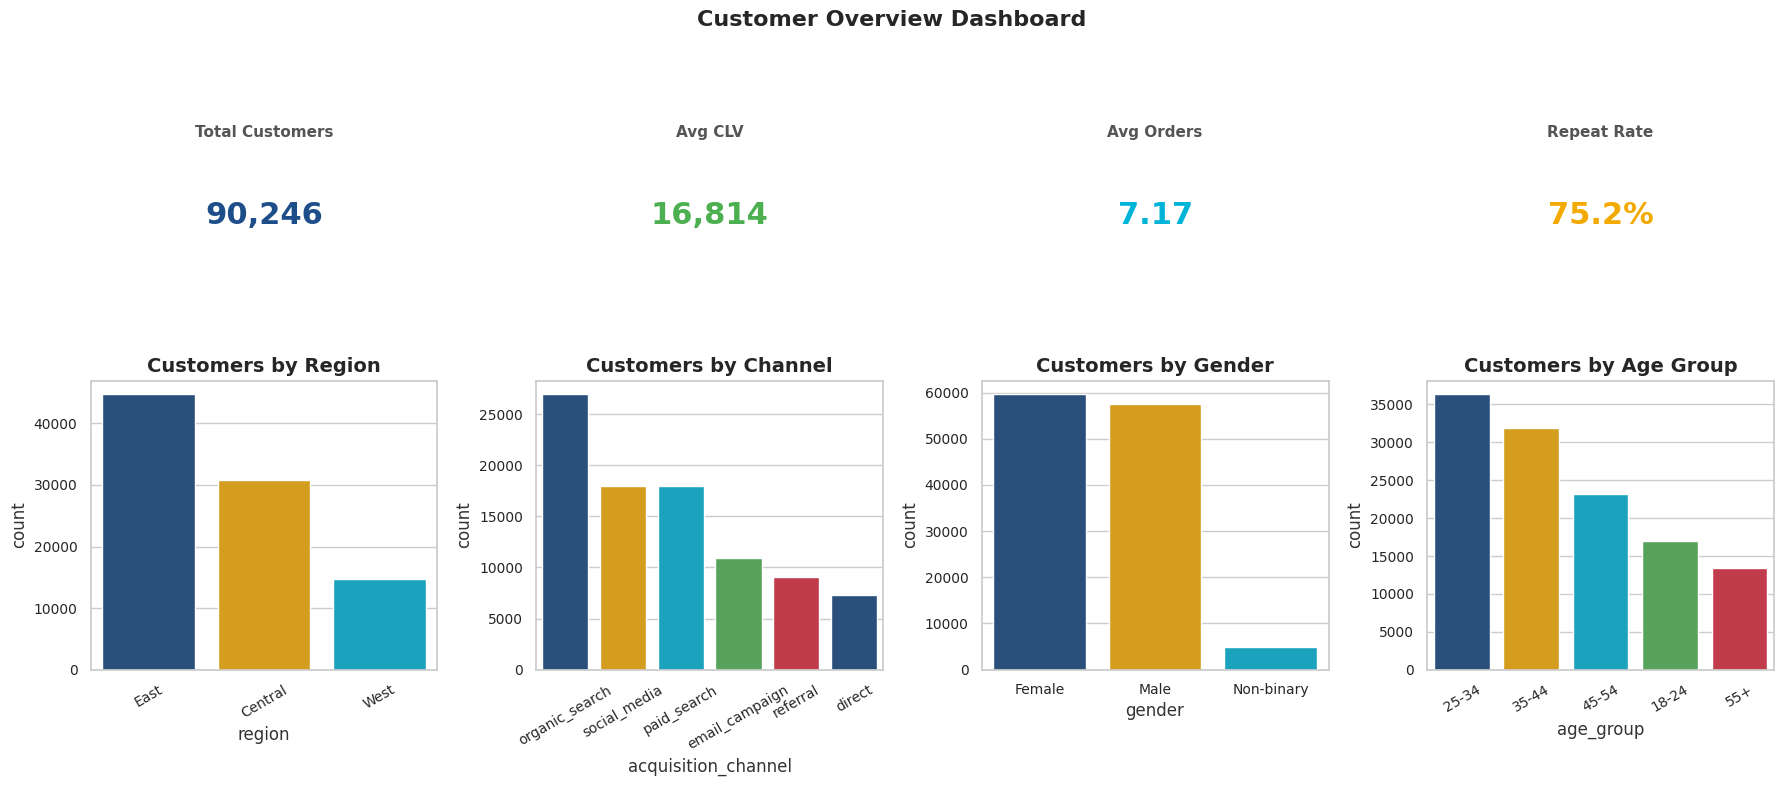

In [ ]:
# ==============================
# CUSTOMER OVERVIEW DASHBOARD
# ==============================

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# ==============================
# KPI CARDS
# ==============================

total_customers = customer_df['customer_id'].nunique()
avg_clv = customer_df['CLV'].mean()
avg_orders = customer_df['total_orders'].mean()
repeat_rate = customer_df['repeat_flag'].mean() * 100

kpis = [
    ('Total Customers', f'{total_customers:,.0f}', GRIDBREAKER_COLORS['primary']),
    ('Avg CLV', f'{avg_clv:,.0f}', GRIDBREAKER_COLORS['success']),
    ('Avg Orders', f'{avg_orders:.2f}', GRIDBREAKER_COLORS['info']),
    ('Repeat Rate', f'{repeat_rate:.1f}%', GRIDBREAKER_COLORS['secondary']),
]

for ax, (title, value, color) in zip(axes[0], kpis):
    ax.set_facecolor('#f5f7fa')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.axis('off')

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(color)
        spine.set_linewidth(2)

    ax.text(0.5, 0.7, title, ha='center', fontsize=11, color='#555', fontweight='bold')
    ax.text(0.5, 0.4, value, ha='center', fontsize=22, color=color, fontweight='bold')


# ==============================
# DISTRIBUTIONS
# ==============================

# Region (FIX duplicate)
region_df = df[['customer_id','region']].drop_duplicates()

sns.countplot(
    data=region_df,
    x='region',
    order=region_df['region'].value_counts().index,
    palette=CUSTOM_PALETTE,
    ax=axes[1,0]
)
axes[1,0].set_title('Customers by Region')
axes[1,0].tick_params(axis='x', rotation=30)


# Acquisition Channel
sns.countplot(
    data=customer_df,
    x='acquisition_channel',
    order=customer_df['acquisition_channel'].value_counts().index,
    palette=CUSTOM_PALETTE,
    ax=axes[1,1]
)
axes[1,1].set_title('Customers by Channel')
axes[1,1].tick_params(axis='x', rotation=30)


# Gender
sns.countplot(
    data=customers,
    x='gender',
    order=customers['gender'].value_counts().index,
    palette=CUSTOM_PALETTE,
    ax=axes[1,2]
)
axes[1,2].set_title('Customers by Gender')


# Age Group
sns.countplot(
    data=customers,
    x='age_group',
    order=customers['age_group'].value_counts().index,
    palette=CUSTOM_PALETTE,
    ax=axes[1,3]
)
axes[1,3].set_title('Customers by Age Group')
axes[1,3].tick_params(axis='x', rotation=30)


plt.suptitle('Customer Overview Dashboard', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Nhận xét chung từ Dashboard Tổng quan Khách hàng:

**1. Sức khỏe Thương hiệu và Lòng trung thành:**
- **Tỷ lệ khách hàng quay lại (Repeat Rate):** Đạt mức ấn tượng **75.2%**. Đây là một chỉ số rất cao, cho thấy sản phẩm có độ bám dính (stickiness) tốt và khách hàng có xu hướng trung thành. Doanh nghiệp đang khai thác hiệu quả tập khách hàng hiện có.
- **Số đơn hàng trung bình:** Mỗi khách hàng đặt trung bình **7.17 đơn hàng**, củng cố thêm nhận định về tần suất mua hàng khá tốt của tập khách hàng.

**2. Kênh thu hút khách hàng và Tiềm năng tăng trưởng:**
- **Kênh thu hút (Acquisition Channel):** **Organic Search** là kênh dẫn đầu, chiếm tỷ trọng cao nhất. Điều này cho thấy thương hiệu có uy tín tự nhiên tốt và khách hàng chủ động tìm kiếm sản phẩm. Điều này cũng góp phần giảm chi phí thu hút khách hàng (CAC).
- **Các kênh trả phí:** **Paid Search** và **Social Media** cũng đóng góp đáng kể, cho thấy doanh nghiệp đang triển khai chiến lược marketing đa kênh một cách hiệu quả.

**3. Đặc điểm Nhân khẩu học:**
- **Nhóm tuổi:** Tập trung mạnh vào nhóm **25-34** và **35-44**, đây là những nhóm tuổi thường có sức mua cao và ổn định, là đối tượng khách hàng tiềm năng.
- **Giới tính:** Tỷ lệ khách hàng nữ cao hơn một chút so với nam, cho thấy có thể sản phẩm hoặc chiến lược tiếp thị đang thu hút phái nữ tốt hơn.

**4. Phân bổ theo Khu vực:**
- **Vùng East** chiếm tỷ trọng lớn nhất về số lượng khách hàng, gần gấp đôi so với vùng West và Central. Điều này cho thấy sự tập trung khách hàng không đồng đều giữa các khu vực.

#### Insights:

- **Ưu điểm lớn về Retention:** Tỷ lệ Repeat Rate cao là một lợi thế cạnh tranh lớn. Doanh nghiệp cần tiếp tục xây dựng các chiến lược duy trì và phát triển mối quan hệ với nhóm khách hàng hiện tại để tối đa hóa giá trị vòng đời khách hàng (CLV).
- **Cơ hội mở rộng thị trường:** Sự chênh lệch lớn về số lượng khách hàng giữa các vùng (đặc biệt là vùng East vượt trội) cho thấy tiềm năng phát triển ở các vùng **West** và **Central**. Cần nghiên cứu sâu hơn lý do vùng East nổi bật và liệu có thể áp dụng các chiến lược tương tự sang các vùng khác hay không, hoặc các vùng khác có đang gặp trở ngại về logistics, phân phối, hoặc marketing.
- **Tận dụng kênh Organic:** Thành công của Organic Search là minh chứng cho một thương hiệu mạnh và chiến lược SEO hiệu quả. Duy trì và đầu tư vào kênh này là cần thiết để tiếp tục giảm chi phí thu hút khách hàng.
- **Cá nhân hóa marketing:** Với dữ liệu về giới tính và nhóm tuổi, doanh nghiệp có thể cá nhân hóa thông điệp và sản phẩm để phù hợp hơn với từng phân khúc, đặc biệt là nhóm tuổi 25-44 và nhóm khách hàng nữ, nhằm tối ưu hiệu quả chuyển đổi và tăng cường sự gắn kết.

## 2.2 Purchase Behavior

In [ ]:
print('Descriptive statistics for customer behavior metrics:')
print(customer_df[['total_orders', 'AOV', 'freq_per_month', 'category_diversity', 'promo_usage_rate']].describe())

Descriptive statistics for customer behavior metrics:
       total_orders            AOV  freq_per_month  category_diversity  \
count  90246.000000   90246.000000    90246.000000        90246.000000   
mean       7.168683   24045.714128        7.809882            1.959333   
std        8.629654   14669.554275       13.258841            0.934528   
min        1.000000     438.940000        0.015852            1.000000   
25%        2.000000   14775.513333        0.070876            1.000000   
50%        4.000000   22258.648125        0.128068            2.000000   
75%        9.000000   29979.322933       30.000000            3.000000   
max      107.000000  202022.560000      105.000000            4.000000   

       promo_usage_rate  
count      90246.000000  
mean           0.384171  
std            0.317832  
min            0.000000  
25%            0.000000  
50%            0.357143  
75%            0.526316  
max            1.000000  


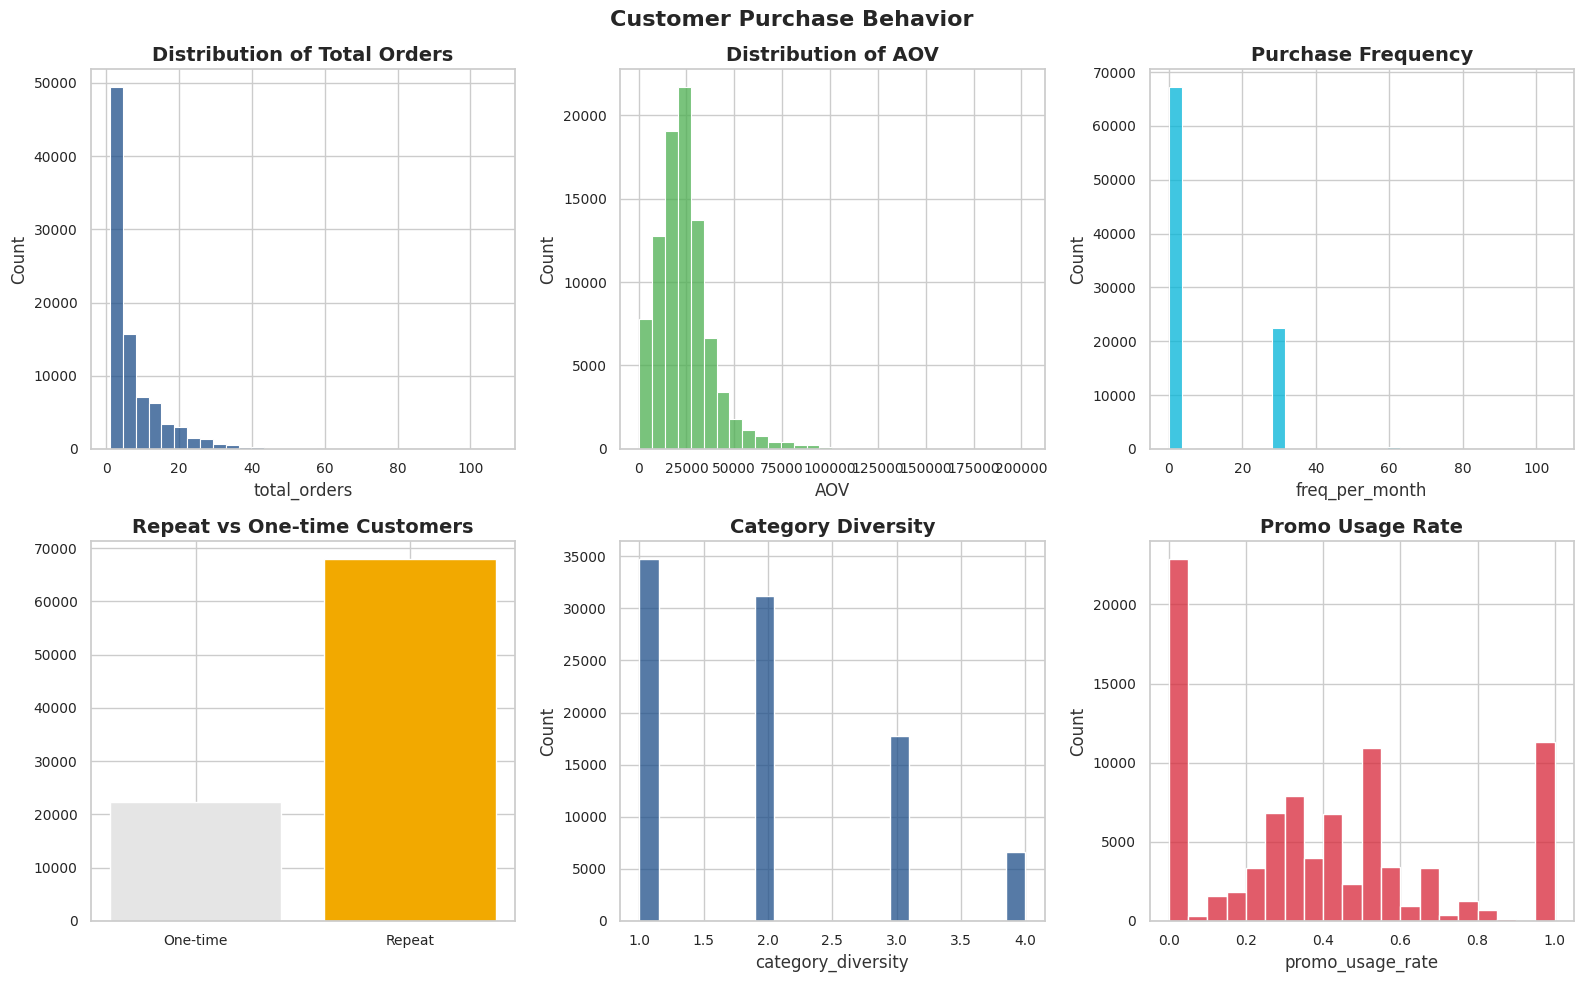

In [ ]:
# ==============================
# PURCHASE BEHAVIOR DASHBOARD
# ==============================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ==============================
# DISTRIBUTION
# ==============================

# Total Orders
sns.histplot(
    customer_df['total_orders'],
    bins=30,
    color=GRIDBREAKER_COLORS['primary'],
    ax=axes[0,0]
)
axes[0,0].set_title('Distribution of Total Orders')


# AOV
sns.histplot(
    customer_df['AOV'],
    bins=30,
    color=GRIDBREAKER_COLORS['success'],
    ax=axes[0,1]
)
axes[0,1].set_title('Distribution of AOV')


# Frequency
sns.histplot(
    customer_df['freq_per_month'],
    bins=30,
    color=GRIDBREAKER_COLORS['info'],
    ax=axes[0,2]
)
axes[0,2].set_title('Purchase Frequency')


# ==============================
# BEHAVIOR INSIGHT
# ==============================

# Repeat vs One-time
repeat_counts = customer_df['repeat_flag'].value_counts()

axes[1,0].bar(
    ['One-time','Repeat'],
    repeat_counts.sort_index(),
    color=[GRIDBREAKER_COLORS['neutral'], GRIDBREAKER_COLORS['secondary']]
)
axes[1,0].set_title('Repeat vs One-time Customers')


# Category Diversity
sns.histplot(
    customer_df['category_diversity'],
    bins=20,
    color=GRIDBREAKER_COLORS['primary'],
    ax=axes[1,1]
)
axes[1,1].set_title('Category Diversity')


# Promo Usage
sns.histplot(
    customer_df['promo_usage_rate'],
    bins=20,
    color=GRIDBREAKER_COLORS['alert'],
    ax=axes[1,2]
)
axes[1,2].set_title('Promo Usage Rate')


plt.suptitle('Customer Purchase Behavior', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

| Metric                         | Observation                              | Key Insight                                                  | Business Implication                                                  |
| ------------------------------ | ---------------------------------------- | ------------------------------------------------------------ | --------------------------------------------------------------------- |
| **Total Orders**               | Mean = 7.17, Median = 4, Max = 107       | Phân phối lệch phải mạnh, tồn tại nhóm khách mua rất nhiều   | Doanh thu phụ thuộc vào **nhóm heavy users**, cần giữ chân nhóm này   |
| **AOV**                        | Mean ≈ 24k, Median ≈ 22k                 | Giá trị đơn hàng khá ổn định, không biến động lớn            | Tăng trưởng không đến từ tăng giá trị đơn → cần tăng **tần suất mua** |
| **Frequency (freq_per_month)** | Mean = 7.8 nhưng Median rất thấp (~0.13) | Phần lớn khách mua rất ít, một nhóm nhỏ mua cực thường xuyên | Customer base không đồng đều → cần **segmentation (RFM)**             |
| **Category Diversity**         | Mean ≈ 2, Max = 4                        | Khách thường chỉ mua 1–2 category                            | Cross-sell chưa hiệu quả → cơ hội tăng doanh thu                      |
| **Promo Usage Rate**           | Mean ≈ 38%, Median ≈ 35%, Max = 100%     | Tồn tại 2 nhóm: không dùng promo vs phụ thuộc promo          | Promo có thể đang **ăn vào profit**, cần tối ưu chiến lược            |


| Area           | Recommendation                                                 |
| -------------- | -------------------------------------------------------------- |
| Retention      | Tập trung giữ chân nhóm khách mua nhiều (high-frequency users) |
| Revenue Growth | Cần identify và bảo vệ nhóm high-frequency customers thay vì cố tăng AOV                             |
| Cross-sell     | Gợi ý sản phẩm để tăng category diversity                      |
| Promotion      | Cá nhân hoá promo, tránh giảm giá đại trà                      |


1. Phân tích Tỷ lệ lưu giữ và Lòng trung thành (Retention & Loyalty)

Dữ liệu ghi nhận chỉ số Lưu giữ khách hàng (Customer Retention Rate) ở mức $75.2\%$. Đây là một chỉ số thống kê phản ánh tính bám dính (stickiness) cực kỳ cao của hệ sinh thái sản phẩm. Việc phần lớn doanh thu được đóng góp bởi nhóm khách hàng cũ cho thấy doanh nghiệp đã thiết lập được lòng trung thành thương hiệu (Brand Loyalty) vững chắc, giúp tối ưu hóa đáng kể Giá trị vòng đời khách hàng (Customer Lifetime Value - CLV).

2. Cấu trúc Kênh thu hút và Nhân khẩu học (Acquisition & Demographics)

Chiến lược tiếp cận: Kênh Organic Search giữ vai trò chủ đạo trong việc thu hút khách hàng mới, minh chứng cho hiệu quả của chiến lược marketing tự nhiên và uy tín thương hiệu nội tại. Điều này trực tiếp làm giảm Chi phí thu hút khách hàng (Customer Acquisition Cost - CAC).Phân khúc trọng tâm: Nhóm đối tượng trong độ tuổi $25-44$ chiếm tỷ trọng áp đảo. Đây là phân khúc có thu nhập khả dụng (disposable income) cao và hành vi tiêu dùng ổn định, đóng vai trò là động lực tăng trưởng chính của đơn vị.


3. Phân tích Hình thái Phân phối Thống kê (Statistical Distribution)

Phân phối lệch phải (Right-skewed Distribution): Biểu đồ Total Orders và Frequency thể hiện hình thái lệch phải rõ rệt. Sự hiện diện của các giá trị ngoại lai (outliers) – nhóm khách hàng có tần suất mua hàng cực lớn (~30 đơn/tháng) – gợi ý về sự tồn tại của phân khúc khách hàng bán buôn (resellers) hoặc các đơn vị mua sắm tập trung.Số trung bình và Trung vị: Sự chênh lệch giữa $Mean$ ($7.17$) và $Median$ ($4$) cho thấy con số trung bình đang bị chi phối bởi nhóm "Heavy Users", không phản ánh hoàn toàn hành vi của đa số khách hàng tiêu chuẩn.


4. Đa dạng hóa Danh mục và Hành vi

Sự thâm nhập danh mục (Category Penetration): Chỉ số Category Diversity thấp (phổ biến ở mức $1-2$ danh mục) chỉ ra rằng khách hàng hiện đang trung thành với một dòng sản phẩm cụ thể hơn là toàn bộ hệ thống. Điều này phản ánh sự thiếu hụt trong chiến lược bán chéo (cross-selling).Phân phối lưỡng đỉnh trong sử dụng ưu đãi (Bi-modal Distribution): Biểu đồ Promo Usage Rate xuất hiện hai đỉnh rõ rệt tại $0\%$ và $100\%$. Hiện tượng này phân tách khách hàng thành hai nhóm đối lập:Nhóm không nhạy cảm về giá (mua hàng dựa trên nhu cầu thực tế).Nhóm có độ co giãn của cầu theo giá (Price Elasticity of Demand) cực lớn (chỉ phát sinh giao dịch khi có kích cầu).

5. Kết luận và Khuyến nghị chiến lược

Tổng thể mô hình kinh doanh đang vận hành dựa trên nền tảng khách hàng trung thành bền vững. Tuy nhiên, để tối ưu hóa biên lợi nhuận và mở rộng quy mô, doanh nghiệp cần:Chiến lược cá nhân hóa ưu đãi: Giảm thiểu trợ giá cho nhóm không nhạy cảm về giá và thiết kế các chương trình kích cầu riêng biệt cho nhóm "Bargain Hunters".Mở rộng chiều sâu danh mục: Tăng cường thuật toán gợi ý để cải thiện chỉ số Category Diversity, tận dụng tệp khách hàng sẵn có để tăng doanh thu mà không làm tăng CAC.Quản trị phân khúc ngoại lai: Thiết lập cơ chế chăm sóc riêng cho nhóm "Heavy Users" để bảo vệ dòng tiền ổn định trước các biến động thị trường

### **2.2.1.RFM Segmentation**

RFM là một mô hình heuristic (rule-based):

| Component         | Ý nghĩa                                   |
| ----------------- | ----------------------------------------- |
| **R (Recency)**   | Khách mua gần đây → khả năng quay lại cao |
| **F (Frequency)** | Mua nhiều lần → loyalty                   |
| **M (Monetary)**  | Chi tiêu nhiều → value                    |
--------------------------------------------------------------------

| Segment           | Đặc điểm hành vi               | Insight                            | Business Action                             |
| ----------------- | ------------------------------ | ---------------------------------- | ------------------------------------------- |
| **VIP**           | Mua gần đây + mua thường xuyên | Nhóm giá trị cao nhất              | Giữ chân bằng loyalty program, ưu đãi riêng |
| **Loyal**         | Mua nhiều nhưng không recent   | Có dấu hiệu giảm engagement        | Retarget bằng email / promo nhẹ             |
| **New Potential** | Mới mua gần đây + chi tiêu cao | Khách tiềm năng                    | Upsell + cross-sell ngay                    |
| **Big Spender**   | Chi nhiều nhưng không frequent | Giá trị cao nhưng chưa trung thành | Tăng frequency (membership, subscription)   |
| **Regular**       | Hành vi trung bình             | Không nổi bật                      | Nudging nhẹ (recommendation, bundle)        |
| **Churn Risk**    | Lâu không mua                  | Nguy cơ rời bỏ                     | Win-back campaign (discount, reactivation)  |



---------------------------------------------------------------
**Mục tiêu:**

- Chuẩn hoá R, F, M về cùng scale (1–5)

- Dễ segmentation

- Robust với skewed data


In [ ]:
# ==============================
# BUILD RFM SCORE
# ==============================

rfm = customer_df[['customer_id', 'recency', 'total_orders', 'total_revenue']].copy()

# Rename cho rõ nghĩa
rfm.columns = ['customer_id', 'R', 'F', 'M']


# ==============================
# SCORING (1 → 5)
# ==============================

# Recency (càng thấp càng tốt → đảo label)
rfm['R_score'] = pd.qcut(
    rfm['R'],
    5,
    labels=[5,4,3,2,1]   # đảo ngược
)

# Frequency (càng cao càng tốt)
rfm['F_score'] = pd.qcut(
    rfm['F'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

# Monetary (càng cao càng tốt)
rfm['M_score'] = pd.qcut(
    rfm['M'],
    5,
    labels=[1,2,3,4,5]
)

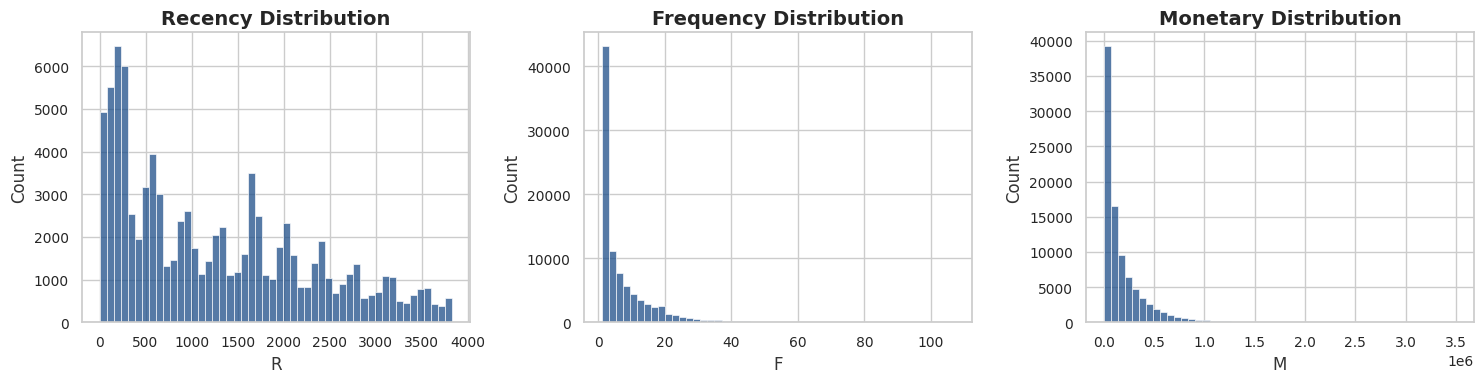

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

sns.histplot(rfm['R'], bins=50, ax=axes[0])
axes[0].set_title("Recency Distribution")

sns.histplot(rfm['F'], bins=50, ax=axes[1])
axes[1].set_title("Frequency Distribution")

sns.histplot(rfm['M'], bins=50, ax=axes[2])
axes[2].set_title("Monetary Distribution")

plt.tight_layout()
plt.show()

#### Nhận xét về phân phối RFM:

*   **Recency (R)**: Phân phối lệch trái, cho thấy phần lớn khách hàng đã mua hàng gần đây. Điều này chỉ ra một tệp khách hàng tương đối tích cực.
*   **Frequency (F)**: Phân phối lệch phải rõ rệt, với đa số khách hàng mua rất ít lần, và một số ít khách hàng mua rất thường xuyên. Điều này gợi ý sự hiện diện của "heavy users" nhưng cũng cho thấy phần lớn khách hàng có tần suất mua thấp.
*   **Monetary (M)**: Cũng lệch phải, cho thấy đa số khách hàng chi tiêu ở mức trung bình, nhưng có một nhóm nhỏ những khách hàng "chi đậm" (big spenders) đóng góp đáng kể vào tổng doanh thu.

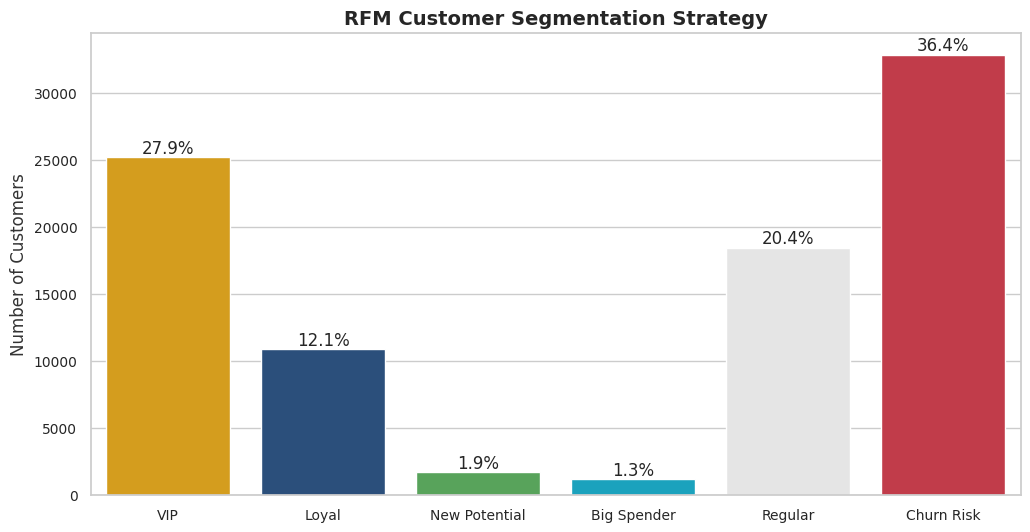

In [ ]:
import numpy as np

# 1. Tối ưu phân đoạn bằng np.select
def get_optimized_segments(df):
    # Chuyển score sang int để so sánh
    r = df['R_score'].astype(int)
    f = df['F_score'].astype(int)
    m = df['M_score'].astype(int)

    conditions = [
        (r >= 4) & (f >= 4),           # VIP: Mua gần, mua nhiều
        (r < 4)  & (f >= 4),           # Loyal: Mua nhiều nhưng bắt đầu rời xa
        (r >= 4) & (f < 4) & (m >= 4), # Potential Big Spender: Khách mới, chi đậm
        (r <= 2),                      # Churn Risk: Đã quá lâu không mua
        (m >= 4)                       # Big Spender: Chi nhiều (nếu chưa lọt các nhóm trên)
    ]

    choices = ['VIP', 'Loyal', 'New Potential', 'Churn Risk', 'Big Spender']

    return np.select(conditions, choices, default='Regular')

rfm['segment'] = get_optimized_segments(rfm)

# 2. Mapping màu sắc cụ thể cho từng Segment để Storytelling tốt hơn
segment_colors = {
    'VIP': GRIDBREAKER_COLORS['secondary'],   # Vàng (Quý giá)
    'Loyal': GRIDBREAKER_COLORS['primary'],    # Xanh đậm (Bền vững)
    'New Potential': GRIDBREAKER_COLORS['success'], # Xanh lá (Tiềm năng)
    'Churn Risk': GRIDBREAKER_COLORS['alert'], # Đỏ (Nguy hiểm)
    'Big Spender': GRIDBREAKER_COLORS['info'], # Xanh nhạt
    'Regular': GRIDBREAKER_COLORS['neutral']   # Xám (Nền)
}

# 3. Vẽ biểu đồ với thứ tự và màu sắc có chủ đích
setup_chart_style()
plt.figure(figsize=(12, 6))

order = ['VIP', 'Loyal', 'New Potential', 'Big Spender', 'Regular', 'Churn Risk']
ax = sns.countplot(data=rfm, x='segment', order=order, palette=segment_colors, hue='segment', legend=False)

plt.title('RFM Customer Segmentation Strategy')
plt.ylabel('Number of Customers')
plt.xlabel('') # Bỏ label X cho thoáng vì tên segment đã rõ

# Add thêm % ở trên mỗi cột
total = len(rfm)
for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')

plt.show()

**Churn Risk (Nguy cơ rời bỏ)**: Đây là phân khúc lớn nhất, chiếm khoảng 36.4% tổng số khách hàng. Điều này là một tín hiệu đáng báo động, cho thấy một lượng lớn khách hàng có khả năng không quay lại mua hàng.

**VIP**: Nhóm khách hàng VIP chiếm khoảng 27.9%. Đây là những khách hàng có giá trị cao, thường xuyên mua sắm và mua gần đây nhất. Họ là tài sản quan trọng nhất của doanh nghiệp.

**Regular (Khách hàng thông thường)**: Phân khúc này chiếm khoảng 20.4%. Đây là nhóm khách hàng có hành vi mua sắm ở mức trung bình, cần được khuyến khích để tăng tần suất và giá trị đơn hàng.

**Loyal (Trung thành):** Nhóm khách hàng trung thành chiếm khoảng 12.1%. Họ mua hàng thường xuyên nhưng có thể không còn quá "recent", cần các chiến lược để duy trì sự gắn kết.

**New Potential (Tiềm năng mới):** Chiếm một tỷ lệ nhỏ, khoảng 1.9%. Đây là những khách hàng mới mua gần đây và có thể có giá trị monetary cao, cần được chăm sóc để phát triển thành VIP hoặc Loyal.

**Big Spender (Chi tiêu lớn):** Phân khúc này cũng khá nhỏ, khoảng 1.3%. Họ chi tiêu nhiều nhưng có thể không mua thường xuyên, cần các chiến lược để tăng tần suất mua.

/tmp/ipykernel_563/2557540046.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_563/2557540046.py:38: UserWarning: 
The palette list has fewer values (5) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(
/tmp/ipykernel_563/2557540046.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_563/2557540046.py:60: UserWarning: 
The palette list has fewer values (5) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
/tmp/ipykernel_563/2557540046.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to

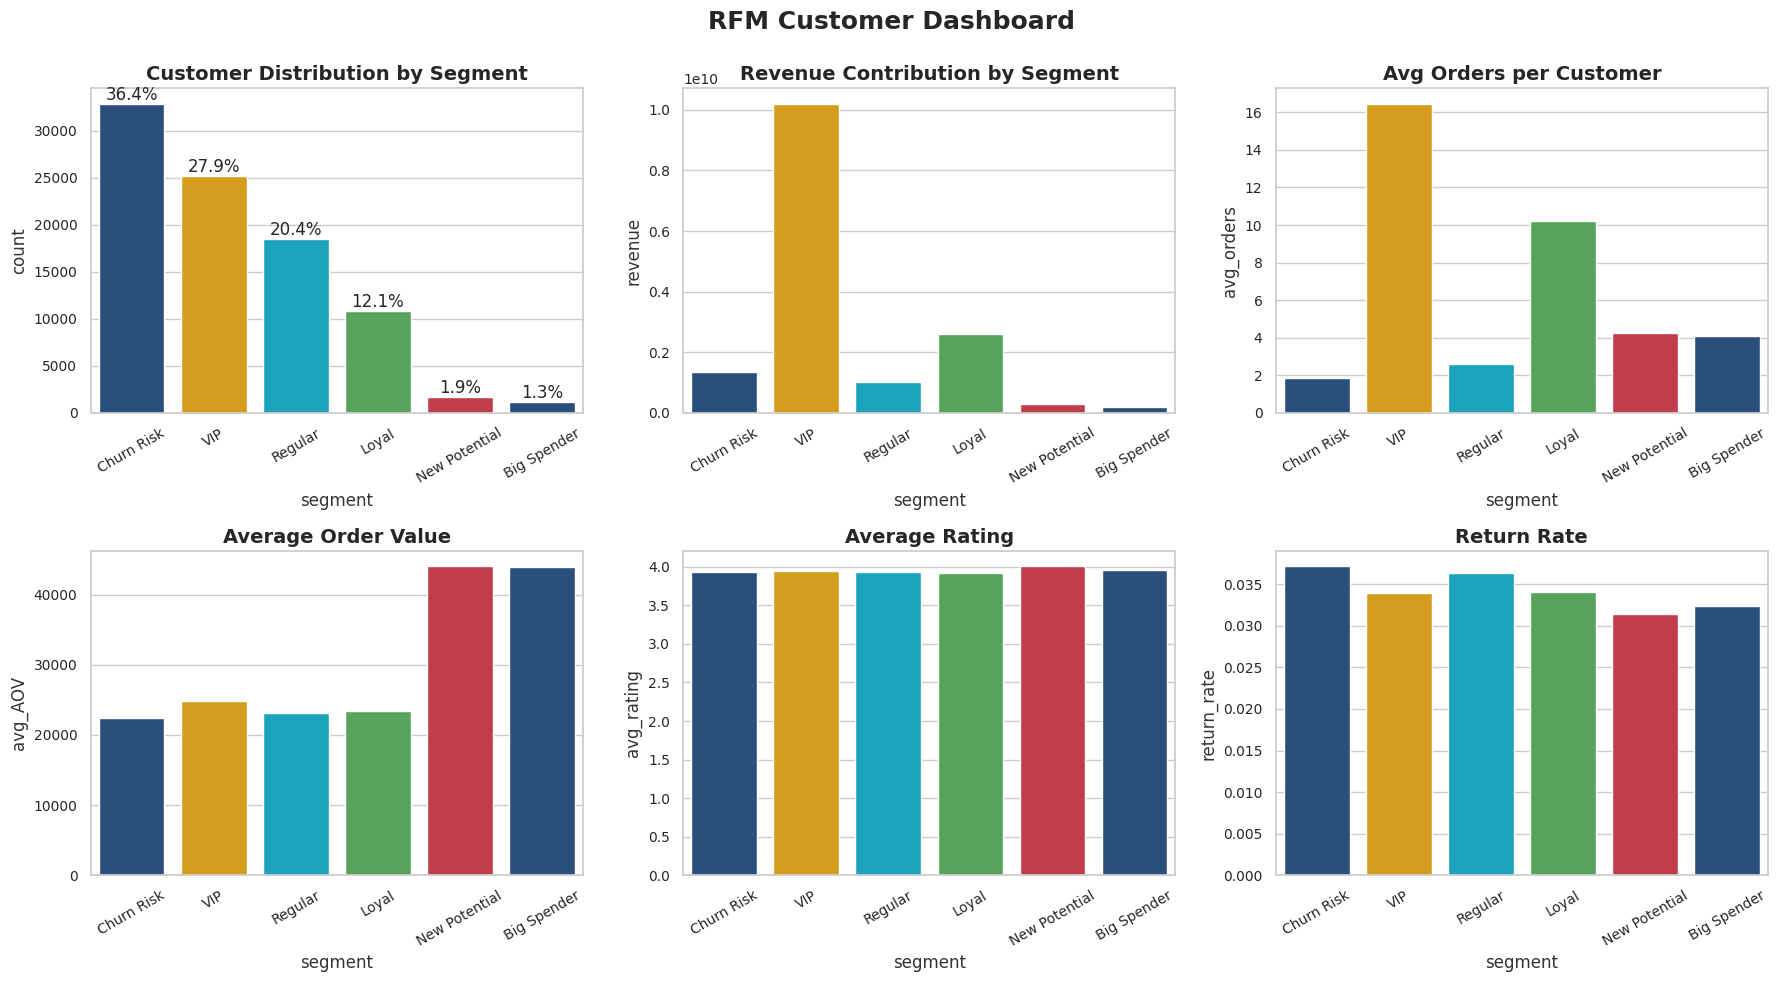

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# PREP DATA
# ==============================

rfm_merged = rfm.merge(customer_df, on='customer_id', how='left')

segment_order = rfm_merged['segment'].value_counts().index

segment_summary = (
    rfm_merged
    .groupby('segment')
    .agg(
        customers=('customer_id','count'),
        revenue=('total_revenue','sum'),
        profit=('total_profit','sum'), # Added profit aggregation
        avg_AOV=('AOV','mean'),
        avg_orders=('total_orders','mean'),
        avg_rating=('avg_rating','mean'),
        return_rate=('return_rate','mean')

    )
    .reset_index()
)

# ==============================
# DASHBOARD
# ==============================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ------------------------------
# 1. Segment Distribution
# ------------------------------
ax = axes[0,0]
sns.countplot(
    data=rfm_merged,
    x='segment',
    order=segment_order,
    palette=CUSTOM_PALETTE,
    ax=ax
)

ax.set_title('Customer Distribution by Segment')

# add %
total = len(rfm_merged)
for p in ax.patches:
    pct = f"{100 * p.get_height()/total:.1f}%"
    ax.annotate(pct,
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

# ------------------------------
# 2. Revenue by Segment
# ------------------------------
ax = axes[0,1]
sns.barplot(
    data=segment_summary,
    x='segment',
    y='revenue',
    order=segment_order,
    palette=CUSTOM_PALETTE,
    ax=ax
)

ax.set_title('Revenue Contribution by Segment')

# ------------------------------
# 3. Avg Order Behavior
# ------------------------------
ax = axes[0,2]
sns.barplot(
    data=segment_summary,
    x='segment',
    y='avg_orders',
    order=segment_order,
    palette=CUSTOM_PALETTE,
    ax=ax
)

ax.set_title('Avg Orders per Customer')

# ------------------------------
# 4. AOV
# ------------------------------
ax = axes[1,0]
sns.barplot(
    data=segment_summary,
    x='segment',
    y='avg_AOV',
    order=segment_order,
    palette=CUSTOM_PALETTE,
    ax=ax
)

ax.set_title('Average Order Value')

# ------------------------------
# 5. Satisfaction
# ------------------------------
ax = axes[1,1]
sns.barplot(
    data=segment_summary,
    x='segment',
    y='avg_rating',
    order=segment_order,
    palette=CUSTOM_PALETTE,
    ax=ax
)

ax.set_title('Average Rating')

# ------------------------------
# 6. Return Rate
# ------------------------------
ax = axes[1,2]
sns.barplot(
    data=segment_summary,
    x='segment',
    y='return_rate',
    order=segment_order,
    palette=CUSTOM_PALETTE,
    ax=ax
)

ax.set_title('Return Rate')

# ------------------------------
# FINAL TOUCH
# ------------------------------
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('RFM Customer Dashboard', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

#### Nhận xét chi tiết về Bảng điều khiển Khách hàng RFM

Dựa trên bảng điều khiển "RFM Customer Dashboard", chúng ta có thể nhận thấy các đặc điểm nổi bật của từng phân khúc khách hàng như sau:

1.  **VIP (27.9% khách hàng)**:
    *   **Doanh thu:** Đóng góp doanh thu lớn nhất.
    *   **Lợi nhuận:** Tạo ra lợi nhuận cao nhất.
    *   **Tần suất:** Trung bình 16.4 đơn hàng/khách (cao nhất).
    *   **AOV:** AOV khá cao (~40k).
    *   **Đánh giá:** Rating trung bình ổn định (~3.9).
    *   **Tỷ lệ trả hàng:** Tỷ lệ trả hàng thấp (~3.4%).
    *   **Insight:**
    - Đây là nhóm khách hàng giá trị nhất, mang lại phần lớn doanh thu và lợi nhuận, thể hiện sự trung thành và tần suất mua cao.
    - Mặc dù nhóm VIP có tổng chi tiêu và tần suất mua hàng cao nhất (như đã phân tích ở các biểu đồ trước), nhưng giá trị trung bình trên mỗi đơn hàng của họ lại không phải là cao nhất. Điều này cho thấy họ mua nhiều lần với giá trị nhỏ thay vì mua một lần với giá trị lớn.

2.  **Loyal (12.1% khách hàng)**:
    *   **Doanh thu:** Đứng thứ hai về đóng góp doanh thu.
    *   **Lợi nhuận:** Đứng thứ hai về lợi nhuận.
    *   **Tần suất:** Trung bình 10.2 đơn hàng/khách.
    *   **AOV:** AOV trung bình (~23k).
    *   **Đánh giá:** Rating ổn định (~3.9).
    *   **Tỷ lệ trả hàng:** Tỷ lệ trả hàng thấp (~3.4%).
    *   **Insight:** Nhóm này rất trung thành nhưng có thể không "recent" bằng VIP. Họ là nguồn doanh thu ổn định và cần được duy trì.

3.  **Regular (20.4% khách hàng)**:
    *   **Doanh thu:** Đóng góp doanh thu đáng kể.
    *   **Lợi nhuận:** Lợi nhuận ở mức trung bình.
    *   **Tần suất:** Trung bình 2.6 đơn hàng/khách.
    *   **AOV:** AOV thấp nhất (~55k).
    *   **Đánh giá:** Rating ổn định (~3.9).
    *   **Tỷ lệ trả hàng:** Tỷ lệ trả hàng cao thứ hai (~3.6%).
    *   **Insight:** Nhóm khách hàng này có hành vi trung bình, cần được khuyến khích để tăng tần suất và AOV.

4.  **Churn Risk (36.4% khách hàng)**:
    *   **Doanh thu:** Vẫn đóng góp một phần doanh thu.
    *   **Lợi nhuận:** Lợi nhuận thấp.
    *   **Tần suất:** Trung bình 1.8 đơn hàng/khách (thấp nhất).
    *   **AOV:** AOV thấp (~22k).
    *   **Đánh giá:** Rating ổn định (~3.9).
    *   **Tỷ lệ trả hàng:** Tỷ lệ trả hàng cao nhất (~3.7%).
    *   **Insight:** Đây là nhóm lớn nhất và đáng lo ngại nhất. Tỷ lệ trả hàng cao và tần suất mua thấp cho thấy trải nghiệm không tốt hoặc thiếu gắn kết.

5.  **New Potential (1.9% khách hàng)**:
    *   **Doanh thu:** Đóng góp doanh thu tốt so với số lượng.
    *   **Lợi nhuận:** Lợi nhuận khá.
    *   **Tần suất:** Trung bình 4.2 đơn hàng/khách.
    *   **AOV:** AOV cao nhất (~44k).
    *   **Đánh giá:** Rating cao nhất (~4.0).
    *   **Tỷ lệ trả hàng:** Tỷ lệ trả hàng thấp nhất (~3.1%).
    *   **Insight:** Nhóm này có tiềm năng lớn với AOV cao và rating tốt, cần được nuôi dưỡng để trở thành VIP.

6.  **Big Spender (1.3% khách hàng)**:
    *   **Doanh thu:** Đóng góp doanh thu đáng kể so với số lượng.
    *   **Lợi nhuận:** Lợi nhuận khá.
    *   **Tần suất:** Trung bình 4.1 đơn hàng/khách.
    *   **AOV:** AOV cao thứ hai (~43k).
    *   **Đánh giá:** Rating khá cao (~4.0).
    *   **Tỷ lệ trả hàng:** Tỷ lệ trả hàng thấp (~3.2%).
    *   **Insight:** Họ chi tiêu nhiều nhưng tần suất không cao, cần khuyến khích mua sắm thường xuyên hơn để tăng Lifetime Value.

**Tóm lại:** Doanh nghiệp có một nền tảng khách hàng VIP và Loyal vững chắc, nhưng đang đối mặt với một tỷ lệ lớn khách hàng có nguy cơ rời bỏ. Các nhóm New Potential và Big Spender là những mục tiêu quan trọng để phát triển trong tương lai.

In [ ]:
# Tính toán giá trị trung bình thực tế cho mỗi phân khúc
segment_profile = rfm.groupby('segment').agg(
    Customer_Count=('customer_id', 'count'),
    Avg_Recency=('R', 'mean'),
    Avg_Frequency=('F', 'mean'),
    Avg_Monetary=('M', 'mean')
).reindex(order).reset_index()

# Hiển thị bảng tóm tắt
print(segment_profile)

         segment  Customer_Count  Avg_Recency  Avg_Frequency   Avg_Monetary
0            VIP           25213   262.797009      16.445762  404257.318798
1          Loyal           10885  1212.382361      10.224162  239705.210772
2  New Potential            1673   311.388524       4.237896  174787.381172
3    Big Spender            1170  1026.041026       4.092308  165153.854256
4        Regular           18455   693.837876       2.602276   55897.849680
5     Churn Risk           32850  2400.511568       1.860122   41457.965093


In [ ]:
segment_summary['revenue_pct'] = (
    segment_summary['revenue'] /
    segment_summary['revenue'].sum()
) * 100

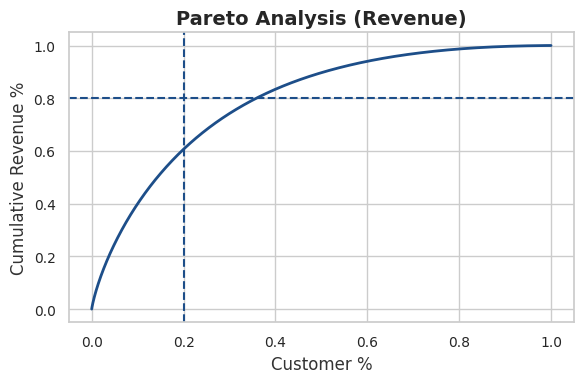

In [ ]:
rev_df = (
    order_df
    .groupby('customer_id', as_index=False)
    .agg(total_revenue=('total_revenue', 'sum'))
    .sort_values(by='total_revenue', ascending=False)
)

# ---- Guard: tránh chia 0
total_rev = rev_df['total_revenue'].sum()

if total_rev == 0:
    raise ValueError("Total revenue = 0 → không thể tính Pareto")

# ---- Cumulative
rev_df['cum_revenue'] = rev_df['total_revenue'].cumsum()
rev_df['cum_pct'] = rev_df['cum_revenue'] / total_rev

# ---- Customer %
rev_df['customer_pct'] = np.arange(1, len(rev_df)+1) / len(rev_df)

# ==============================
# PLOT
# ==============================

plt.figure(figsize=(6,4))

plt.plot(
    rev_df['customer_pct'],
    rev_df['cum_pct'],
    linewidth=2
)

# 80/20 reference lines
plt.axhline(y=0.8, linestyle='--')
plt.axvline(x=0.2, linestyle='--')

plt.xlabel('Customer %')
plt.ylabel('Cumulative Revenue %')
plt.title('Pareto Analysis (Revenue)')

plt.grid(True)
plt.tight_layout()
plt.show()

**Insight:**

- Biểu đồ Pareto cho thấy doanh thu của chúng ta phụ thuộc cực kỳ lớn vào nhóm khách hàng top đầu (VIP & Loyal). Chỉ cần 20% khách hàng này rời đi, doanh nghiệp sẽ mất ngay 60% tổng doanh thu.

- Lỗ hổng quy tắc Pareto (Tỷ lệ 40/80): Thông thường, quy tắc Pareto kỳ vọng 20% khách hàng tạo ra 80% doanh thu. Tuy nhiên, tại đây 20% khách hàng hàng đầu mới chỉ tạo ra ~60% doanh thu. Phải cần đến 40% khách hàng mới chạm được mốc 80% doanh thu.  

=>  Doanh nghiệp không bị phụ thuộc quá mức vào một nhóm khách hàng siêu nhỏ, giúp giảm rủi ro "mất khách lớn"



**Next Question**: Segment nào đóng góp bao nhiêu % revenue và nằm ở đâu trên đường Pareto?

In [ ]:
import numpy as np
import pandas as pd

# Sort theo Monetary giảm dần
rfm_sorted = rfm.sort_values(by='M', ascending=False).reset_index(drop=True)

# Tổng revenue
total_revenue = rfm_sorted['M'].sum()

# Cumulative revenue
rfm_sorted['cum_revenue'] = rfm_sorted['M'].cumsum()
rfm_sorted['cum_pct'] = rfm_sorted['cum_revenue'] / total_revenue

# Customer %
rfm_sorted['customer_pct'] = (rfm_sorted.index + 1) / len(rfm_sorted)

In [ ]:
segment_summary = rfm.groupby('segment').agg(
    Customer_Count=('customer_id', 'count'),
    Revenue=('M', 'sum')
).reset_index()

segment_summary['Customer_%'] = segment_summary['Customer_Count'] / len(rfm)
segment_summary['Revenue_%'] = segment_summary['Revenue'] / total_revenue

segment_summary.sort_values(by='Revenue_%', ascending=False)

,segment,Customer_Count,Revenue,Customer_%,Revenue_%
5,VIP,25213,1.019254e+10,0.279381,0.649998
2,Loyal,10885,2.609191e+09,0.120615,0.166393
1,Churn Risk,32850,1.361894e+09,0.364005,0.086851
4,Regular,18455,1.031595e+09,0.204497,0.065787
3,New Potential,1673,2.924193e+08,0.018538,0.018648
0,Big Spender,1170,1.932300e+08,0.012965,0.012323


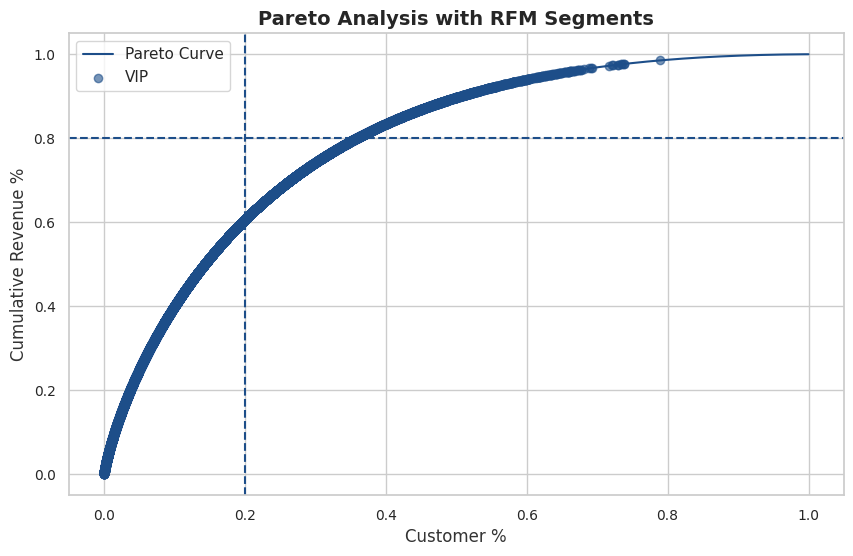

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Pareto line
plt.plot(rfm_sorted['customer_pct'], rfm_sorted['cum_pct'], label='Pareto Curve')

# Highlight VIP points
vip_mask = rfm_sorted['segment'] == 'VIP'
plt.scatter(
    rfm_sorted.loc[vip_mask, 'customer_pct'],
    rfm_sorted.loc[vip_mask, 'cum_pct'],
    label='VIP',
    alpha=0.6
)

plt.axhline(0.8, linestyle='--')
plt.axvline(0.2, linestyle='--')

plt.title("Pareto Analysis with RFM Segments")
plt.xlabel("Customer %")
plt.ylabel("Cumulative Revenue %")
plt.legend()
plt.show()

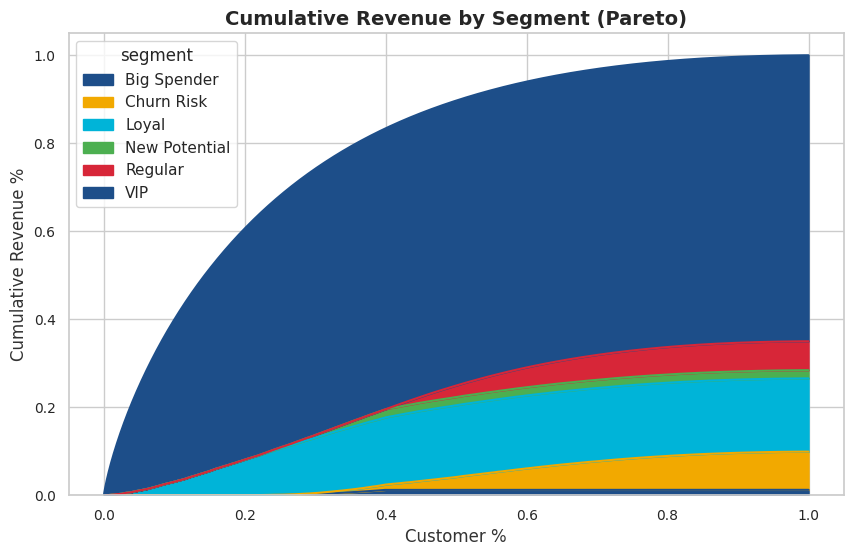

In [ ]:
# cumulative revenue by segment
rfm_sorted['segment_cum_revenue'] = rfm_sorted.groupby('segment')['M'].cumsum()

# pivot để stacked plot
pivot = rfm_sorted.pivot_table(
    index='customer_pct',
    columns='segment',
    values='M',
    aggfunc='sum'
).fillna(0)

pivot = pivot.cumsum() / total_revenue

pivot.plot.area(figsize=(10,6))

plt.title("Cumulative Revenue by Segment (Pareto)")
plt.xlabel("Customer %")
plt.ylabel("Cumulative Revenue %")
plt.show()

**Finding 1 — Revenue concentration**

- VIP có Monetary ~404K, gấp ~10 lần Churn Risk

Ý nghĩa:

- Revenue tập trung mạnh vào nhóm VIP

- Đây là dấu hiệu classic của Pareto (80/20)

-> Business đang phụ thuộc vào small group khách hàng


-------------------------------------------------------------------------------


**Finding 2 — Retention problem**

> Churn Risk = 32,850 customers (lớn nhất)
> Recency = 2400 ngày (~6.5 năm)

Ý nghĩa:
Rất nhiều khách đã “chết hoàn toàn” và Funnel đang leak sau first purchase

-> Customer base is heavily skewed toward inactive users


--------------------------------------------------------------------------------
**Finding 3 — Hidden risk: Loyal đang trượt**

Loyal:

> Frequency cao (10.2)

> Nhưng Recency = 1212 (đang rời xa)

Đây là nhóm high-value nhưng đang rơi vào churn-> Không cứu → mất revenue lớn


--------------------------------------------------------------------------------

**Finding 4 — High-value nhưng inactive**

Big Spender: Monetary cao VS Recency rất cao (1026) -> Đây là khách từng chi mạnh nhưng đã “ngủ đông”

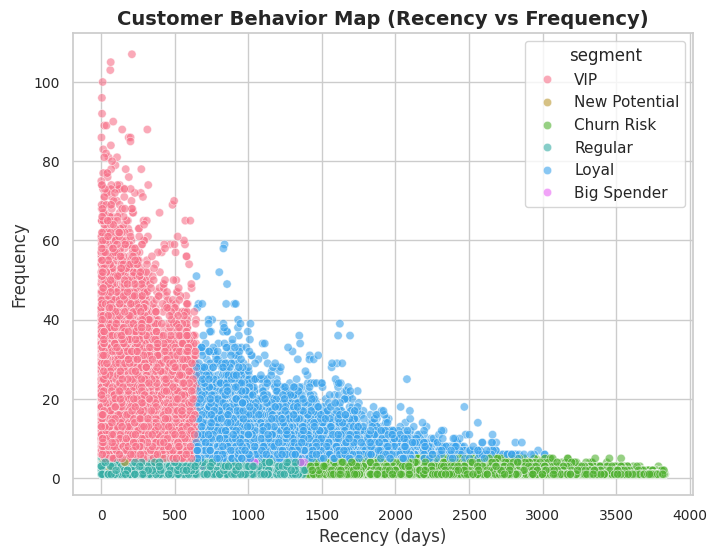

In [ ]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=rfm,
    x='R',
    y='F',
    hue='segment',
    alpha=0.6
)

plt.title("Customer Behavior Map (Recency vs Frequency)")
plt.xlabel("Recency (days)")
plt.ylabel("Frequency")
plt.show()

/tmp/ipykernel_9169/648481249.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  heatmap_data = rfm.pivot_table(


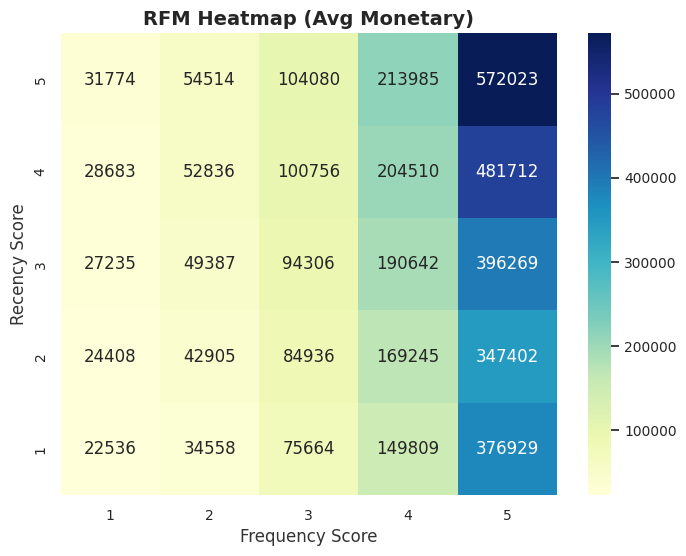

In [ ]:
heatmap_data = rfm.pivot_table(
    index='R_score',
    columns='F_score',
    values='M',
    aggfunc='mean'
)

plt.figure(figsize=(8,6))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap='YlGnBu')

plt.title("RFM Heatmap (Avg Monetary)")
plt.xlabel("Frequency Score")
plt.ylabel("Recency Score")
plt.show()

#### Nhận xét về RFM Heatmap (Avg Monetary)

Heatmap trực quan hóa mối quan hệ giữa Recency, Frequency và giá trị chi tiêu trung bình (Monetary) của khách hàng, qua đó làm rõ cấu trúc giá trị trong tập khách hàng.

#### 1. Phân bố giá trị theo hành vi khách hàng

Giá trị Monetary cao nhất tập trung tại vùng có **Recency và Frequency cao (R=5, F=5)**, xác nhận rằng những khách hàng mua gần đây và mua thường xuyên là nhóm đóng góp doanh thu lớn nhất. Đây chính là nhóm khách hàng cốt lõi (VIP).

Ngược lại, các vùng có **Recency thấp và Frequency thấp** ghi nhận mức chi tiêu trung bình rất thấp, cho thấy nhóm khách hàng này gần như không còn đóng góp đáng kể vào doanh thu.

---

#### 2. Xu hướng suy giảm giá trị

Giá trị Monetary giảm rõ rệt khi:
- Recency giảm (khách hàng không còn mua gần đây)
- Frequency giảm (khách hàng mua ít thường xuyên hơn)

Đặc biệt, sự suy giảm theo Recency có xu hướng mạnh hơn, cho thấy **mức độ tương tác gần đây là yếu tố nhạy cảm đối với giá trị khách hàng**.

---

#### 3. Vai trò kết hợp của Recency và Frequency

Heatmap cho thấy giá trị khách hàng không chỉ phụ thuộc vào một yếu tố riêng lẻ, mà là kết quả của sự kết hợp giữa:
- Tính “freshness” (Recency)
- Tính “habitual” (Frequency)

Những khách hàng có Frequency cao nhưng Recency thấp (ví dụ: từng mua nhiều nhưng đã lâu không quay lại) vẫn có giá trị thấp hơn đáng kể so với nhóm còn hoạt động gần đây.

---

#### 4. Phân hóa giá trị rõ ràng giữa các nhóm

Biểu đồ thể hiện sự phân tầng rõ rệt:
- Nhóm giá trị cao: tập trung ở vùng trên bên phải
- Nhóm giá trị trung bình: phân bố ở vùng trung tâm
- Nhóm giá trị thấp: tập trung ở vùng dưới bên trái

Điều này cho thấy hệ thống khách hàng có cấu trúc phân hóa mạnh, phù hợp với kết quả từ phân tích RFM và Pareto trước đó.

---

#### 5. Phát hiện bổ sung (nâng cao)

Một số vùng đáng chú ý:
- **High Frequency nhưng Recency thấp**: nhóm khách hàng từng trung thành nhưng đang rời bỏ  
- **High Recency nhưng Frequency thấp**: nhóm khách hàng mới hoặc chưa hình thành thói quen mua  

Đây là hai nhóm có tiềm năng can thiệp cao, có thể mang lại hiệu quả nếu được xử lý đúng chiến lược.

---

#### 6. Ý nghĩa kinh doanh

Heatmap xác nhận rằng:
- Giá trị khách hàng phụ thuộc mạnh vào khả năng duy trì tương tác liên tục  
- Việc mất đi “recency” sẽ kéo theo giảm mạnh giá trị, ngay cả với khách hàng từng có tần suất mua cao  

Điều này nhấn mạnh vai trò của **retention và re-engagement** trong việc duy trì doanh thu.

---

#### 7. Đề xuất hành động

- Tập trung giữ chân nhóm khách hàng có Recency cao để duy trì giá trị hiện tại  
- Triển khai chiến dịch tái kích hoạt cho nhóm có Frequency cao nhưng Recency giảm  
- Thúc đẩy tăng tần suất mua cho nhóm khách hàng mới (Recency cao, Frequency thấp)  
- Ưu tiên phân bổ nguồn lực marketing vào các vùng có tiềm năng chuyển đổi cao thay vì nhóm giá trị thấp  

---

#### Kết luận

Heatmap củng cố rằng Recency và Frequency là hai yếu tố cốt lõi quyết định giá trị khách hàng.  
Chiến lược tối ưu nên tập trung vào việc duy trì tính liên tục trong hành vi mua hàng và chuyển đổi khách hàng tiềm năng thành khách hàng trung thành nhằm tối đa hóa giá trị vòng đời khách hàng.

**CORE FINDING**: Thách thức cốt lõi của doanh nghiệp không nằm ở bài toán acquisition, mà nằm ở bài toán retention và customer lifecycle optimization

### Final takeaway

### Customer Segment Distribution & Revenue Contribution

#### 1. Segment nào chiếm nhiều nhất? Có bị lệch về churn không?

Phân tích phân bổ khách hàng cho thấy **Churn Risk là phân khúc lớn nhất**, chiếm khoảng **36.4% tổng số khách hàng**. Đây là một tín hiệu đáng quan ngại, cho thấy một tỷ lệ lớn khách hàng đã mất tương tác và có khả năng không quay lại mua hàng.

Các phân khúc còn lại bao gồm:

- **VIP (27.9%)**: Nhóm khách hàng giá trị cao, mua thường xuyên và gần đây  
- **Regular (20.4%)**: Nhóm khách hàng có mức độ tương tác trung bình  
- **Loyal (12.1%)**: Mua hàng thường xuyên nhưng không còn gần đây  
- **New Potential (1.9%)**: Khách hàng mới với tiềm năng cao  
- **Big Spender (1.3%)**: Chi tiêu lớn nhưng tần suất mua thấp  

Kết quả này cho thấy cơ cấu khách hàng đang **lệch đáng kể về phía nhóm có nguy cơ rời bỏ**, phản ánh vấn đề trong việc duy trì khách hàng.

---

#### 2. VIP chiếm bao nhiêu % revenue?

Nhóm **VIP chiếm khoảng 27.9% tổng số khách hàng** nhưng đóng góp tới **khoảng 65.0% tổng doanh thu**.

Điều này cho thấy doanh thu phụ thuộc mạnh vào một nhóm khách hàng tương đối nhỏ, và nhóm VIP đóng vai trò trung tâm trong việc tạo ra giá trị kinh doanh.

---

#### 3. Có tuân theo quy luật 80/20 không?

Phân tích Pareto cho thấy:

- **20% khách hàng hàng đầu tạo ra khoảng 60% doanh thu**

So với quy luật 80/20 tiêu chuẩn, mức độ tập trung doanh thu trong trường hợp này là **chưa tối ưu**, cho thấy doanh thu vẫn phân bổ tương đối rộng trên nhiều nhóm khách hàng.

---

#### 4. Insight tổng hợp

Kết hợp RFM và Pareto cho thấy:

- Doanh thu tập trung chủ yếu vào nhóm **VIP và Loyal (chiếm khoảng 81.6%)**
- Trong khi đó, nhóm **Churn Risk chiếm hơn 36% khách hàng nhưng đóng góp chưa đến 9% doanh thu**

Điều này cho thấy một phần lớn khách hàng không tạo ra giá trị đáng kể, làm giảm hiệu quả tổng thể của hệ thống khách hàng.

---

#### 5. Ý nghĩa kinh doanh

Doanh nghiệp hiện đang phụ thuộc đáng kể vào một nhóm nhỏ khách hàng giá trị cao. Nếu nhóm này suy giảm, doanh thu sẽ bị ảnh hưởng nghiêm trọng.

Đồng thời, việc duy trì một lượng lớn khách hàng có giá trị thấp làm gia tăng chi phí vận hành và marketing nhưng không mang lại hiệu quả tương xứng.

---

#### 6. Đề xuất hành động

- Tập trung vào việc duy trì và gia tăng giá trị từ nhóm VIP và Loyal thông qua các chương trình cá nhân hóa và chăm sóc khách hàng  
- Triển khai các chiến lược tái kích hoạt đối với nhóm Loyal và Big Spender trước khi họ chuyển sang trạng thái churn  
- Xây dựng cơ chế chuyển đổi nhóm Regular và New Potential thành khách hàng trung thành  
- Tối ưu chi phí marketing bằng cách giảm đầu tư vào nhóm Churn Risk có giá trị thấp  

---

#### Kết luận

Vấn đề cốt lõi của doanh nghiệp không nằm ở việc thu hút khách hàng mới, mà nằm ở khả năng duy trì và phát triển giá trị khách hàng hiện tại. Chiến lược trong tương lai nên ưu tiên vào việc tăng tỷ lệ giữ chân và tối đa hóa giá trị vòng đời khách hàng.

### **2.2.2. Product Affinity (Market Basket Analysis)**


---

**“Khách hàng mua cái gì cùng nhau → mình nên bán thêm cái gì?”**:


---









In [ ]:
orders_products = orders.merge(order_items, on='order_id') \
                        .merge(products, on='product_id')

In [ ]:
orders_products['revenue'] = (
    orders_products['quantity'] * orders_products['unit_price']
    - orders_products['discount_amount']
)

In [ ]:
orders_products

,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source,product_id,quantity,...,product_name,category,segment,size,color,price,cogs,gross_profit,margin,revenue
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,2400,7,...,VietMotion YY-09,GenZ,Trendy,S,red,1109.261061,1053.798008,55.463053,0.0500,7967.54
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,609,7,...,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231,1438.866803,0.1380,71163.75
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,396,3,...,SaigonFlex UM-01,Streetwear,Balanced,S,green,11028.428695,10091.012256,937.416439,0.0850,33660.99
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,635,5,...,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,10745.220588,9205.430478,1539.790110,0.1433,53196.25
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,1935,1,...,UrbanVN RP-10,Outdoor,Activewear,XL,purple,1609.911509,1048.696357,561.215152,0.3486,1597.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
714664,834372,2022-12-31,19490,33907,delivered,credit_card,mobile,email_campaign,690,8,...,SaigonFlex UC-55,Streetwear,Everyday,L,red,4598.817231,3100.062695,1498.754536,0.3259,35791.36
714665,834377,2022-12-31,73046,37091,delivered,credit_card,mobile,referral,1995,7,...,UrbanVN UM-02,Streetwear,Balanced,XL,purple,5159.312851,3025.421056,2133.891795,0.4136,36755.53
714666,834387,2022-12-31,107723,80516,delivered,credit_card,mobile,email_campaign,2331,8,...,VietMotion UE-05,Streetwear,Performance,XL,black,7365.661770,6671.816431,693.845339,0.0942,59112.48
714667,834392,2022-12-31,139431,93510,delivered,paypal,desktop,direct,1115,5,...,MekongFit RS-03,Outdoor,Premium,XL,purple,4828.925117,4587.478861,241.446256,0.0500,23836.65


In [ ]:
df_mba = orders_products[orders_products['order_status'] == 'delivered'].copy()

In [ ]:
top_products = (
    df_mba['product_name']
    .value_counts()
    .head(2000)
    .index
)

df_mba = df_mba[df_mba['product_name'].isin(top_products)]

In [ ]:
transactions = (
    df_mba
    .groupby('order_id')['product_name']
    .apply(list)
)

In [ ]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions, sparse=True)

basket = pd.DataFrame.sparse.from_spmatrix(te_array, columns=te.columns_)

/tmp/ipykernel_563/1607283714.py:6: FutureWarning: Allowing arbitrary scalar fill_value in SparseDtype is deprecated. In a future version, the fill_value must be a valid value for the SparseDtype.subtype.
  basket = pd.DataFrame.sparse.from_spmatrix(te_array, columns=te.columns_)


In [ ]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.005,   # Reduced min_support to 0.005
    use_colnames=True
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.2
)

rules = rules.sort_values(by='lift', ascending=False)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
rules_filtered = rules[
    (rules['confidence'] >= 0.3) &
    (rules['lift'] >= 1.2)
]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
rules_filtered['rule'] = (
    rules_filtered['antecedents'].astype(str)
    + " → " +
    rules_filtered['consequents'].astype(str)
)

rules_filtered[['rule', 'support', 'confidence', 'lift']].head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,rule,support,confidence,lift
0,frozenset({'HanoiStreet RP-80'}) → frozenset({...,0.007882,0.508743,32.655388
1,frozenset({'HanoiStreet RP-79'}) → frozenset({...,0.007882,0.505963,32.655388


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


#### Phân tích các chỉ số chính của luật kết hợp:

*   **Support (Hỗ trợ) = 0.007882 (0.79%)**: Cả hai mặt hàng này cùng xuất hiện đồng thời trong khoảng 0.79% tổng số giao dịch. Đây là một tỉ lệ xuất hiện ở mức trung bình trong các bài toán giỏ hàng, cho thấy cặp sản phẩm này có sự hiện diện ổn định.

*   **Confidence (Độ tin cậy) ≈ 0.51 (51%)**:
    *   Khi khách hàng mua RP-79, có 50.6% khả năng họ sẽ mua thêm RP-80.
    *   Ngược lại, khi khách hàng mua RP-80, có 50.9% khả năng họ sẽ mua thêm RP-79.
    *   Chỉ số này khá cao, cho thấy một mối liên kết chặt chẽ và tương đối cân bằng từ cả hai phía.

*   **Lift (Độ nâng) = 32.655**: Đây là chỉ số ấn tượng nhất. Lift > 1 (và cụ thể ở đây là rất cao ~32.7) khẳng định rằng việc mua hai sản phẩm này có mối quan hệ phụ thuộc lẫn nhau cực kỳ mạnh mẽ. Khách hàng mua sản phẩm này thì khả năng mua sản phẩm kia cao gấp 32.6 lần so với việc mua ngẫu nhiên.

*   **Zhang's Metric = 0.984**: Chỉ số này gần tiến tới 1, cho thấy sự kết hợp này gần như là hoàn hảo và không phải do ngẫu nhiên.

In [ ]:
# Thử group theo category
transactions = (
    df_mba
    .groupby('order_id')['category']
    .apply(list)
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions, sparse=True)

basket = pd.DataFrame.sparse.from_spmatrix(te_array, columns=te.columns_)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.005,   # Reduced min_support to 0.005
    use_colnames=True
)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.2
)

rules = rules.sort_values(by='lift', ascending=False)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
rules_filtered = rules[
    (rules['confidence'] >= 0.3) &
    (rules['lift'] >= 1.2)
]

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
rules_filtered['rule'] = (
    rules_filtered['antecedents'].astype(str)
    + " → " +
    rules_filtered['consequents'].astype(str)
)

rules_filtered[['rule', 'support', 'confidence', 'lift']].head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,rule,support,confidence,lift


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

### Final takeaway

#### **Nhận xét về bản chất mối quan hệ**
Mối quan hệ tương hỗ (Symmetrical Relationship): Các chỉ số giữa hai chiều (79 -> 80 và 80 -> 79) gần như tương đương nhau. Điều này cho thấy hai sản phẩm này thường được mua cùng nhau như một bộ đôi không thể tách rời.

Sản phẩm đi kèm (Complementary Products): Dựa trên tên gọi (RP-79 và RP-80), có khả năng đây là hai sản phẩm thuộc cùng một dòng hàng, cùng một bộ sưu tập hoặc là các phụ kiện bổ trợ trực tiếp cho nhau.

####  **Đề xuất hành động kinh doanh (Actionable Insights)**
Sắp xếp hàng hóa (Merchandising): Nên đặt hai mặt hàng này cạnh nhau trên kệ hàng vật lý hoặc hiển thị trong phần "Sản phẩm thường được mua cùng nhau" trên website để nhắc nhở khách hàng.

Chiến lược Combo: Tạo các gói Combo (Bundle) gồm cả RP-79 và RP-80 với mức giá ưu đãi nhẹ để kích khích khách hàng mua cả cặp, tăng giá trị trung bình đơn hàng (AOV).

Tiếp thị liên kết (Cross-marketing): Nếu khách hàng chỉ mới bỏ một sản phẩm vào giỏ hàng, hệ thống nên tự động gợi ý sản phẩm còn lại ngay lập tức.

Quản lý kho: Vì hai sản phẩm này có xu hướng "đi cùng nhau", cần đảm bảo mức độ tồn kho của chúng tương đương để tránh tình trạng khách hàng muốn mua cả bộ nhưng một trong hai sản phẩm bị hết hàng.

----

**Khách hàng quay lại mua hàng như thế nào theo thời gian?\\**

---



/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

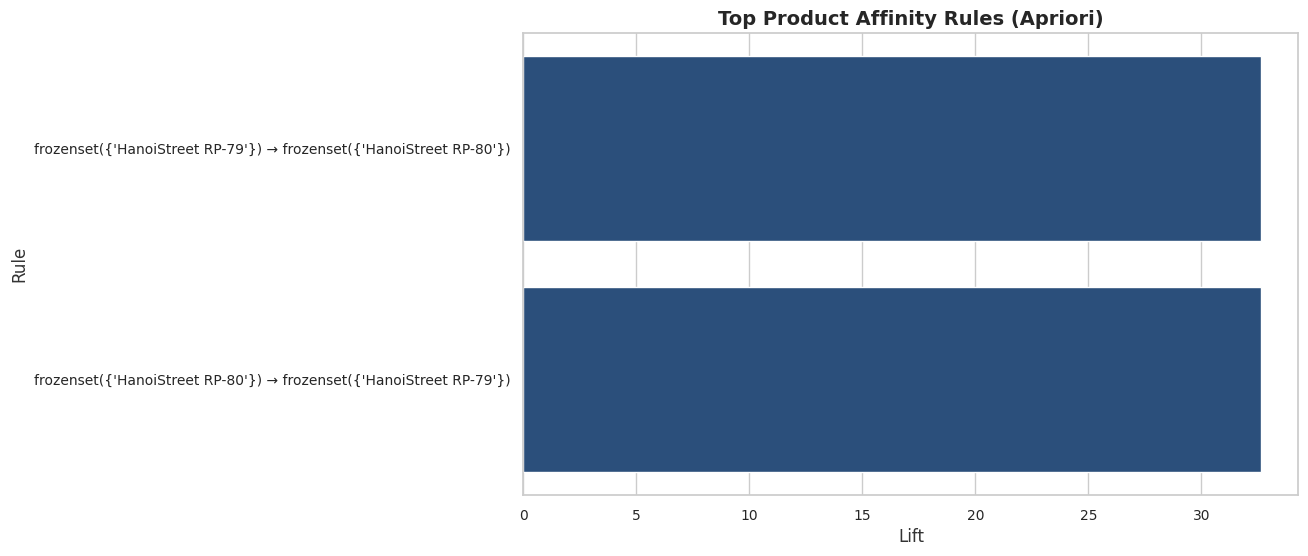

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_rules = rules_filtered.head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_rules['lift'], y=top_rules['rule'])

plt.title("Top Product Affinity Rules (Apriori)")
plt.xlabel("Lift")
plt.ylabel("Rule")
plt.show()

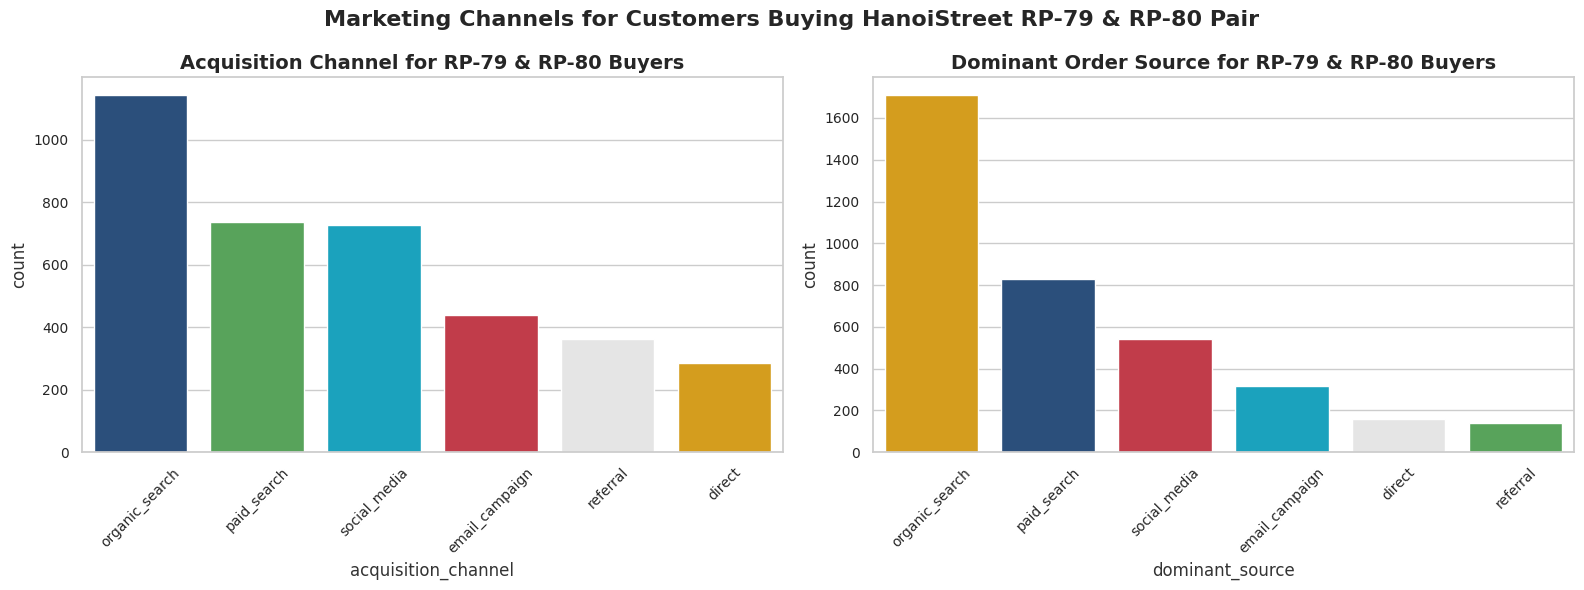


Percentage of RP-79 & RP-80 buyers acquired via Social Media: 19.67%
Percentage of RP-79 & RP-80 buyers whose dominant order source is Social Media: 14.64%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get product_ids for RP-79 and RP-80
rp79_id = products[products['product_name'] == 'HanoiStreet RP-79']['product_id'].iloc[0]
rp80_id = products[products['product_name'] == 'HanoiStreet RP-80']['product_id'].iloc[0]

# Find orders that contain both products
orders_with_rp79 = df_mba[df_mba['product_id'] == rp79_id]['order_id'].unique()
orders_with_rp80 = df_mba[df_mba['product_id'] == rp80_id]['order_id'].unique()

# Identify common orders (where both products were purchased)
orders_both_rp = set(orders_with_rp79).intersection(set(orders_with_rp80))

# Get customer_ids from these orders
customers_both_rp = df_mba[df_mba['order_id'].isin(orders_both_rp)]['customer_id'].unique()

# Merge with customer_df to get channel information
customers_channels = customer_df[customer_df['customer_id'].isin(customers_both_rp)]

# Analyze Acquisition Channel and Dominant Order Source
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(
    data=customers_channels,
    x='acquisition_channel',
    order=customers_channels['acquisition_channel'].value_counts().index,
    palette=CUSTOM_PALETTE,
    hue='acquisition_channel', # Explicitly set hue
    legend=False, # Set legend to False as per warning
    ax=axes[0]
)
axes[0].set_title('Acquisition Channel for RP-79 & RP-80 Buyers')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(
    data=customers_channels,
    x='dominant_source',
    order=customers_channels['dominant_source'].value_counts().index,
    palette=CUSTOM_PALETTE,
    hue='dominant_source', # Explicitly set hue
    legend=False, # Set legend to False as per warning
    ax=axes[1]
)
axes[1].set_title('Dominant Order Source for RP-79 & RP-80 Buyers')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Marketing Channels for Customers Buying HanoiStreet RP-79 & RP-80 Pair', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Further analysis on Social Media specifically
social_media_acquisition_pct = (customers_channels['acquisition_channel'] == 'social_media').mean() * 100
social_media_dominant_source_pct = (customers_channels['dominant_source'] == 'social_media').mean() * 100

print(f"\nPercentage of RP-79 & RP-80 buyers acquired via Social Media: {social_media_acquisition_pct:.2f}%")
print(f"Percentage of RP-79 & RP-80 buyers whose dominant order source is Social Media: {social_media_dominant_source_pct:.2f}%")

**Marketing Channel Analysis for RP-79 & RP-80**

**1. Sức mạnh của Thương hiệu và SEO:**
*   **Organic Search chiếm ưu thế tuyệt đối:** Khách hàng chủ động tìm kiếm các sản phẩm cụ thể của dòng "HanoiStreet", cho thấy bộ đôi RP-79 và RP-80 đã có độ nhận diện thương hiệu rất tốt hoặc các từ khóa liên quan đang đứng top tìm kiếm tự nhiên.

**2. Hiệu quả chuyển đổi của Social Media:**
*   **Social Media đóng vai trò tạo nhận thức:** Mặc dù tỷ lệ tiếp cận qua Social Media là 19.67%, nhưng số lượng đơn hàng thực tế do Social Media dẫn dắt trực tiếp thấp hơn rõ rệt so với Search. Điều này củng cố nhận định rằng Social Media hiệu quả hơn trong việc tạo nhận thức (Awareness) thay vì chốt đơn (Conversion) trực tiếp cho bộ outfit này.

**3. Mối liên hệ giữa Paid Search và Acquisition:**
*   **Paid Search hiệu quả trong nhắm mục tiêu:** Đứng thứ 2 về Acquisition, Paid Search cho thấy các chiến dịch quảng cáo trả phí đang nhắm mục tiêu khá hiệu quả vào những khách hàng đang tìm kiếm các sản phẩm tương tự, dẫn dắt họ mua combo ngay từ lần đầu tiếp cận.

**4. Đề xuất hành động:**
*   **Tăng cường Cross-selling trên Website:** Vì khách hàng chủ yếu đến từ Search (vào thẳng trang sản phẩm), cần thiết lập các banner hoặc widget "Hoàn thiện bộ outfit" ngay tại trang sản phẩm RP-79 để đảm bảo họ không bỏ lỡ RP-80.
*   **Tối ưu hóa hành trình Social:** Cần đơn giản hóa các bước từ lúc khách xem ảnh outfit trên Social Media đến lúc thêm cả hai món vào giỏ hàng (ví dụ: sử dụng link mua sắm trực tiếp toàn bộ set đồ) để thu hẹp khoảng cách giữa tỷ lệ tiếp cận và tỷ lệ chốt đơn.

RFM Segment Distribution for Customers buying HanoiStreet RP-79 & RP-80:
         Segment  Customer_Count  Percentage
0            VIP            2275   61.553030
1          Loyal             661   17.884199
2     Churn Risk             432   11.688312
3        Regular             289    7.819264
4  New Potential              29    0.784632
5    Big Spender              10    0.270563


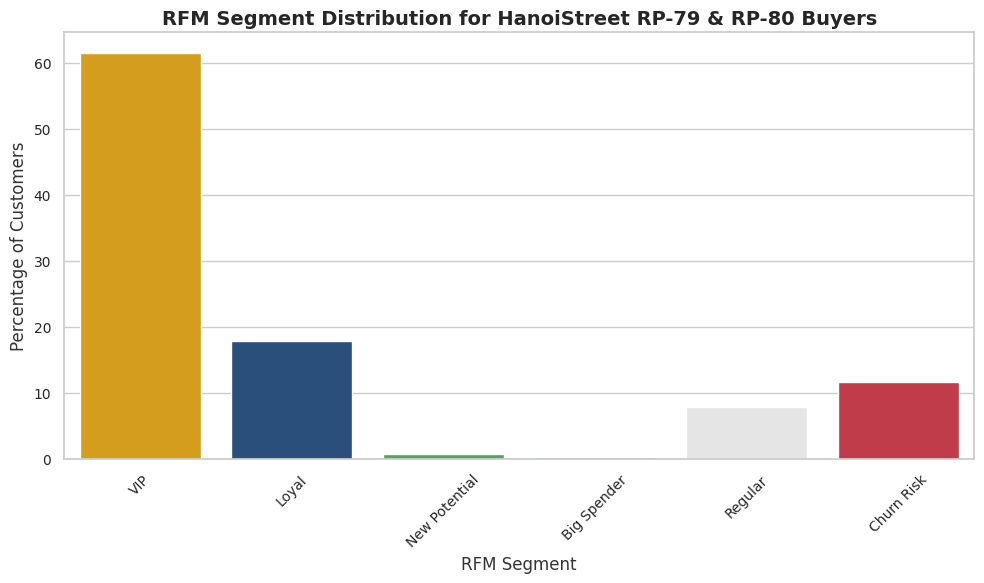

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Merge customers_both_rp with rfm_merged to get segment information
customers_with_segments = rfm_merged[rfm_merged['customer_id'].isin(customers_both_rp)]

# Analyze segment distribution
segment_counts = customers_with_segments['segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Customer_Count']
segment_counts['Percentage'] = (segment_counts['Customer_Count'] / segment_counts['Customer_Count'].sum()) * 100

print("RFM Segment Distribution for Customers buying HanoiStreet RP-79 & RP-80:")
print(segment_counts)

# Visualize the segment distribution
plt.figure(figsize=(10, 6))
order = ['VIP', 'Loyal', 'New Potential', 'Big Spender', 'Regular', 'Churn Risk']
# Filter segment_counts to only include segments in the order list
segment_counts_ordered = segment_counts[segment_counts['Segment'].isin(order)]
sns.barplot(
    data=segment_counts_ordered,
    x='Segment',
    y='Percentage',
    order=order,
    palette=segment_colors,
    hue='Segment',
    legend=False
)
plt.title('RFM Segment Distribution for HanoiStreet RP-79 & RP-80 Buyers')
plt.ylabel('Percentage of Customers')
plt.xlabel('RFM Segment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Nhận xét về Phân phối Khách Hàng RFM cho cặp đôi sản phẩm HanoiStreet RP-79 & RP-80

Phân tích RFM của những khách hàng mua cả hai sản phẩm `HanoiStreet RP-79` và `HanoiStreet RP-80` mang lại những insight quan trọng về giá trị và hành vi của nhóm đối tượng này:

1.  ** Nhóm VIP:**
    *   **61.6% khách hàng** mua cặp đôi này thuộc phân khúc **VIP**. Đây là một tỷ lệ cực kỳ cao, khẳng định rằng những sản phẩm này không chỉ là hàng hóa thông thường mà còn là "biểu tượng lòng trung thành" đối với nhóm khách hàng giá trị nhất. Nhóm VIP có xu hướng mua sắm theo bộ để khẳng định phong cách thiết kế đặc trưng của dòng "HanoiStreet".
    *   Các nhóm khác bao gồm **Loyal (17.9%)** và **Churn Risk (11.7%)**, **Regular (7.8%)**, **New Potential (0.8%)**, **Big Spender (0.3%)**.
    
2.  **Sức mạnh của Tìm kiếm Tự nhiên (SEO):**
    *   Trái với dự đoán về Social Media, `Organic Search` là kênh dẫn dắt chính cho các đơn hàng combo này. Điều này cho thấy khách hàng có xu hướng chủ động tìm kiếm để sở hữu trọn bộ outfit, thay vì chỉ bị thu hút ngẫu hứng từ quảng cáo.

3.  **Chỉ số Lift (32.6):**
    *   Việc mua một sản phẩm kéo theo sản phẩm kia cao gấp 32.6 lần so với trường hợp ngẫu nhiên. Chỉ số Lift cực kỳ cao này cho thấy tính bổ trợ tuyệt đối, gần như là một bộ set không thể tách rời trong tâm trí khách hàng.

**Kết luận và Ý nghĩa Kinh doanh:**

*   **Tập trung vào VIP:** Nhóm khách hàng VIP là cốt lõi cho các sản phẩm "HanoiStreet RP-79" và "HanoiStreet RP-80". Các chiến lược marketing và ưu đãi nên được thiết kế để củng cố lòng trung thành của nhóm này, khuyến khích họ khám phá thêm các bộ sưu tập tương tự.
*   **Tối ưu hóa SEO:** Tiếp tục đầu tư vào SEO để duy trì và tăng cường khả năng hiển thị của các sản phẩm "HanoiStreet". Đảm bảo các từ khóa liên quan đến "bộ sưu tập", "outfit", "phong cách HanoiStreet" được tối ưu.
*   **Chiến lược Combo & Cross-sell:** Tận dụng mối liên hệ chặt chẽ giữa hai sản phẩm bằng cách tạo các gói combo hấp dẫn, hiển thị gợi ý mua kèm nổi bật trên website và các kênh bán hàng. Điều này sẽ giúp tăng giá trị đơn hàng trung bình (AOV) và củng cố trải nghiệm khách hàng.

## 2.3. Cohort

In [ ]:
df_cohort = orders_products.copy()

df_cohort['order_date'] = pd.to_datetime(df_cohort['order_date'])

# Lấy tháng
df_cohort['order_month'] = df_cohort['order_date'].dt.to_period('M')

In [ ]:
df_cohort['cohort_month'] = (
    df_cohort.groupby('customer_id')['order_date']
    .transform('min')
    .dt.to_period('M')
)

In [ ]:
df_cohort['cohort_index'] = (
    (df_cohort['order_month'] - df_cohort['cohort_month'])
    .apply(lambda x: x.n)
)

In [ ]:
cohort_data = (
    df_cohort
    .groupby(['cohort_month', 'cohort_index'])['customer_id']
    .nunique()
    .reset_index()
)

cohort_pivot = cohort_data.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='customer_id'
)

# retention %
cohort_size = cohort_pivot.iloc[:,0]
retention = cohort_pivot.divide(cohort_size, axis=0)

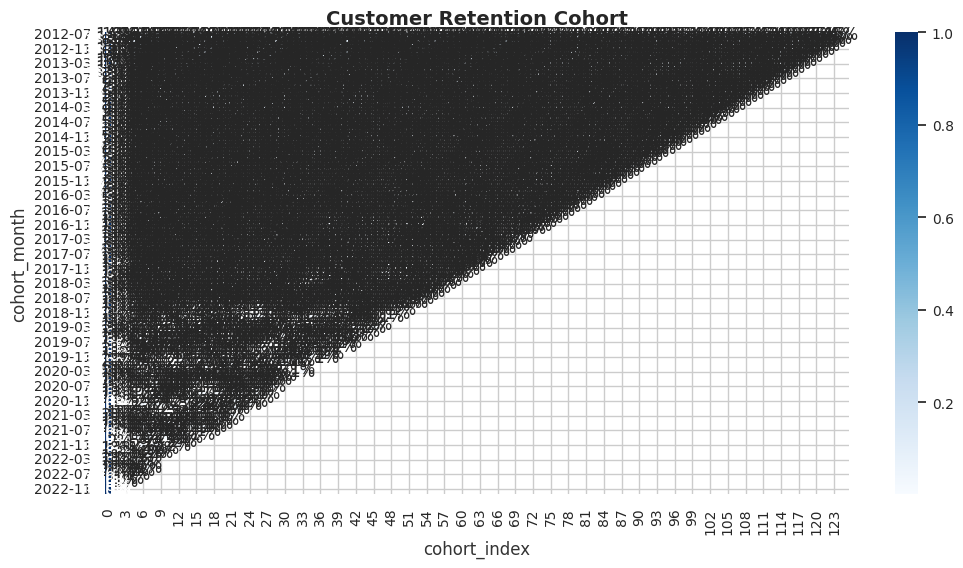

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(retention, annot=True, fmt=".0%", cmap="Blues")

plt.title("Customer Retention Cohort")
plt.show()

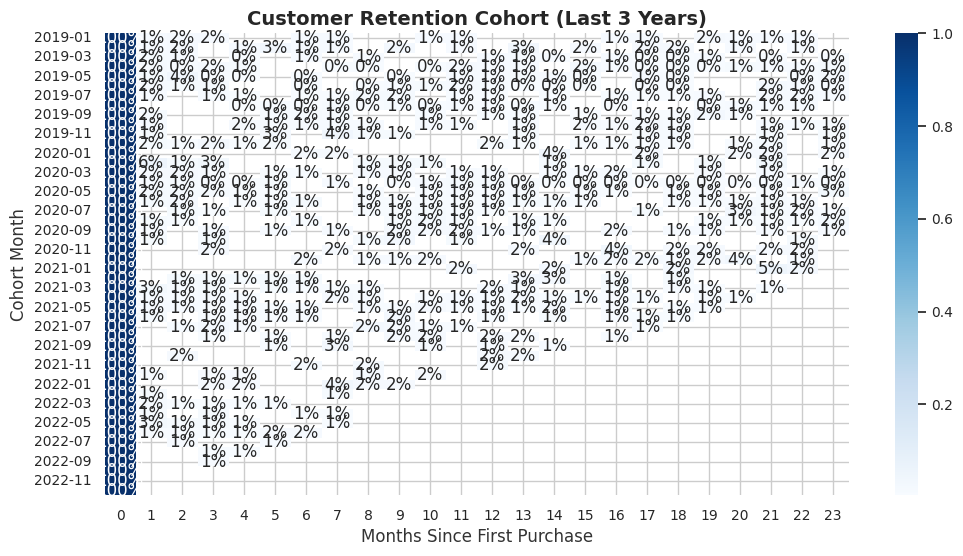

In [ ]:
plt.figure(figsize=(12,6))

sns.heatmap(
    retention.loc['2019':].iloc[:, :24],
    cmap="Blues",
    annot=True,
    fmt=".0%"
)

plt.title("Customer Retention Cohort (Last 3 Years)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

### Final Takeaway: Cohort Analysis — Customer Retention

### 1. What happened? (Descriptive)

Biểu đồ Cohort Retention cho thấy tỷ lệ khách hàng quay lại giảm rất nhanh sau lần mua đầu tiên.

- **Giảm retention nhanh chóng:** Hầu hết các cohort (nhóm khách hàng cùng tháng gia nhập) đều cho thấy sự sụt giảm mạnh về tỷ lệ giữ chân ngay từ tháng thứ 1 đến tháng thứ 3 sau lần mua đầu tiên. Điều này chỉ ra rằng phần lớn khách hàng chỉ mua 1-2 lần rồi không quay lại.
- **Retention ở mức rất thấp:** Sau giai đoạn sụt giảm ban đầu, tỷ lệ giữ chân khách hàng duy trì ở mức rất thấp, thường chỉ khoảng 1-5% trong các tháng tiếp theo. Điều này đồng nghĩa với việc rất ít khách hàng trở thành người mua lặp lại và gắn bó lâu dài.
- **Thiếu sự cải thiện qua thời gian:** Quan sát các cohort từ 2012 đến 2022 (và đặc biệt là 3 năm gần nhất 2019-2022), mô hình giữ chân khách hàng gần như không thay đổi. Điều này cho thấy các chiến lược hiện tại không hiệu quả trong việc cải thiện tỷ lệ giữ chân hoặc không có sự điều chỉnh đáng kể để giải quyết vấn đề này.
- **Không có cohort duy trì retention cao:** Không có bất kỳ nhóm cohort nào thể hiện khả năng duy trì tỷ lệ giữ chân cao trong dài hạn. Điều này là một tín hiệu đáng báo động về khả năng xây dựng lòng trung thành khách hàng của doanh nghiệp.

### 2. Why did it happen? (Diagnostic - Liên kết với các phân tích trước)

Kết quả từ Cohort Analysis củng cố cho các phát hiện từ phân tích RFM và các chẩn đoán khác:

- **Vấn đề cốt lõi về Retention:** Cohort Analysis xác nhận rằng doanh nghiệp đang đối mặt với một vấn đề nghiêm trọng về giữ chân khách hàng. Khả năng thu hút khách hàng mới tốt, nhưng việc biến họ thành khách hàng trung thành, mua sắm thường xuyên là điểm yếu.
- **Churn Risk cao:** Tỷ lệ khách hàng thuộc nhóm 'Churn Risk' cao trong phân tích RFM (36.4%) phản ánh chính xác xu hướng này trên biểu đồ cohort.
- **Trải nghiệm sau mua chưa tốt:** Phân tích chẩn đoán về `delivery_days` đã chỉ ra rằng khách hàng có xu hướng rời đi (churn) mạnh mẽ khi thời gian giao hàng vượt quá 5 ngày, dù rating có thể không giảm ngay lập tức. Đây là một nguyên nhân trực tiếp dẫn đến việc retention giảm sút.
- **Hạn chế của Product Affinity:** Market Basket Analysis cho thấy phần lớn đơn hàng chỉ chứa một sản phẩm và cross-selling tự nhiên không phổ biến. Điều này góp phần làm giảm cơ hội khách hàng quay lại để mua các sản phẩm bổ trợ, ảnh hưởng đến tần suất mua.
- **Tối ưu hóa khuyến mãi chưa hiệu quả:** Mặc dù có các chương trình khuyến mãi, nhưng phân tích tương quan giữa `promo_usage_rate` và `monetary` cho thấy khuyến mãi không thực sự thúc đẩy LTV mà chủ yếu kích thích các giao dịch nhỏ lẻ, thu hút nhóm 'săn sale' kém bền vững.



## 2.4. CLV

In [ ]:
df_clv = orders_products.copy()

df_clv['order_date'] = pd.to_datetime(df_clv['order_date'])
df_clv['order_month'] = df_clv['order_date'].dt.to_period('M')

In [ ]:
df_clv['cohort_month'] = (
    df_clv.groupby('customer_id')['order_date']
    .transform('min')
    .dt.to_period('M')
)

In [ ]:
df_clv['cohort_index'] = (
    (df_clv['order_month'] - df_clv['cohort_month'])
    .apply(lambda x: x.n)
)

In [ ]:
cohort_revenue = (
    df_clv
    .groupby(['cohort_month', 'cohort_index'])['revenue']
    .sum()
    .reset_index()
)

In [ ]:
cohort_pivot = cohort_revenue.pivot(
    index='cohort_month',
    columns='cohort_index',
    values='revenue'
)

In [ ]:
cohort_size = (
    df_clv.groupby('cohort_month')['customer_id']
    .nunique()
)

clv_cohort = cohort_pivot.divide(cohort_size, axis=0)

In [ ]:
clv_cumulative = clv_cohort.cumsum(axis=1)

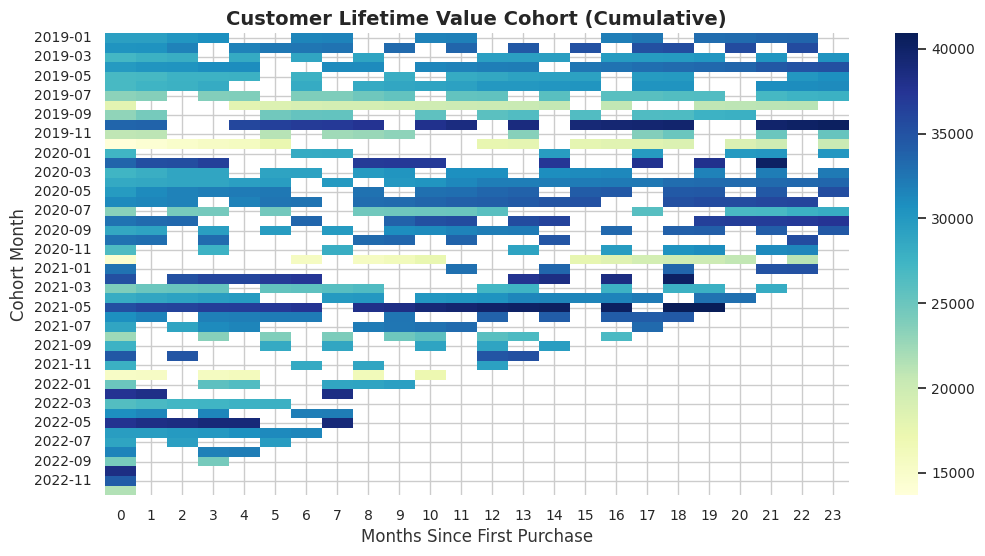

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    clv_cumulative.loc['2019':].iloc[:, :24],
    cmap="YlGnBu"
)

plt.title("Customer Lifetime Value Cohort (Cumulative)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

### Final Takeaway: CLV Cohort Analysis (Cumulative)

#### What happened? (Descriptive)

Biểu đồ CLV Cohort lũy kế cho thấy:

- **Tăng trưởng CLV chậm sau tháng đầu tiên:** Giá trị CLV tăng mạnh trong tháng đầu tiên (cohort index 0), sau đó tốc độ tăng trưởng giảm đáng kể trong các tháng tiếp theo.
- **CLV ổn định nhưng thấp:** Sau vài tháng đầu, CLV của các cohort có xu hướng ổn định ở một mức nhất định, nhưng mức này khá thấp, đặc biệt đối với các cohort cũ hơn.
- **Không có sự cải thiện CLV đáng kể:** Các cohort mới (ví dụ: từ 2021, 2022) không cho thấy CLV lũy kế vượt trội đáng kể so với các cohort cũ (từ 2019, 2020) sau cùng một khoảng thời gian. Điều này cho thấy doanh nghiệp chưa có sự cải thiện trong việc gia tăng giá trị vòng đời khách hàng qua các năm.
- **Dấu hiệu của “cháy nhanh tắt sớm”:** Mức tăng trưởng CLV dồn chủ yếu vào giao dịch đầu tiên hoặc rất sớm, cho thấy khách hàng ít có xu hướng tăng chi tiêu đáng kể theo thời gian.


Nếu không có sự thay đổi chiến lược:

- **CLV bình quân sẽ duy trì ở mức thấp:** Doanh nghiệp sẽ tiếp tục phụ thuộc vào việc thu hút khách hàng mới để duy trì doanh thu, thay vì khai thác giá trị từ tệp khách hàng hiện có.
- **Chi phí thu hút khách hàng (CAC) sẽ tăng cao:** Khi không thể giữ chân và phát triển CLV, doanh nghiệp sẽ phải chi nhiều hơn cho marketing để liên tục tìm kiếm khách hàng mới, ảnh hưởng đến lợi nhuận.
- **Khó khăn trong việc xây dựng thương hiệu bền vững:** CLV thấp là dấu hiệu của việc khách hàng không thực sự gắn bó lâu dài với thương hiệu, làm suy yếu nền tảng để tăng trưởng bền vững.



### 1.1 CLV có tăng theo thời gian không?
CLV nhìn chung có xu hướng tăng theo thời gian ở hầu hết các cohort. Tuy nhiên, mức tăng không ổn định và nhiều cohort dừng tăng khá sớm.

**Insight:**  
Hành vi mua lặp lại có tồn tại nhưng chưa đủ mạnh để tạo tăng trưởng CLV bền vững.

---

### 1.2 Cohort nào hoạt động tốt hơn?
Các cohort giai đoạn 2020 đến đầu 2021 có CLV cao hơn và duy trì tăng trưởng lâu hơn. Ngược lại, các cohort năm 2022 có CLV thấp và tăng trưởng ngắn hạn.

**Insight:**  
Chất lượng khách hàng hoặc hiệu quả acquisition đã giảm ở các cohort gần đây.

---

### 1.3 CLV plateau xảy ra khi nào?
Phần lớn cohort đạt trạng thái plateau trong khoảng tháng 4–8. Một số cohort dừng tăng ngay từ tháng 3–5.

**Insight:**  
Khách hàng churn sớm, không quay lại mua sau giai đoạn đầu.

---

### 1.4 Pattern bất thường
Một số cohort có mức tăng mạnh ban đầu nhưng không duy trì được sau đó.

**Insight:**  
Các chiến dịch ngắn hạn (ví dụ: khuyến mãi mạnh) tạo spike nhưng không giữ chân khách hàng.




In [ ]:
revenue_retention = clv_cohort.divide(clv_cohort.iloc[:,0], axis=0)

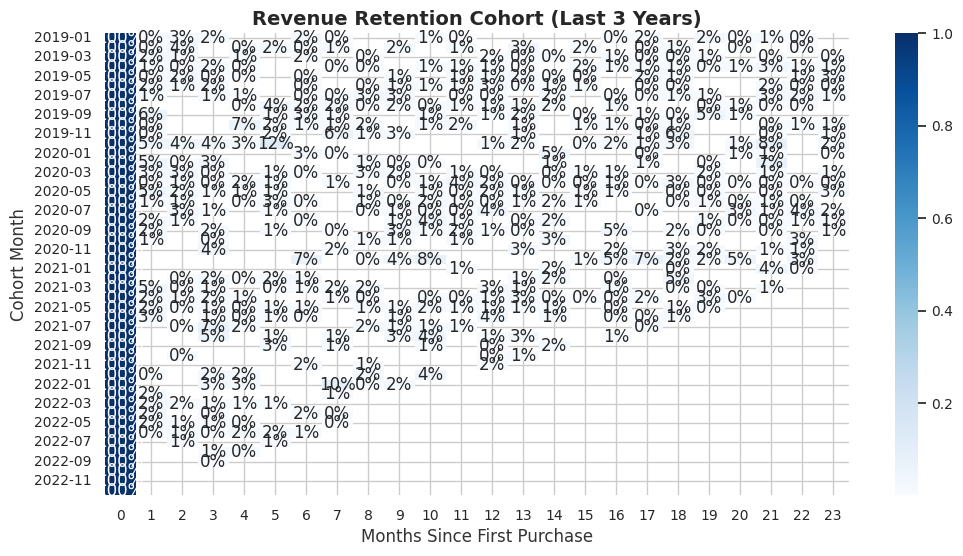

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    revenue_retention.loc['2019':].iloc[:, :24],
    cmap="Blues",
    annot=True,
    fmt=".0%"
)

plt.title("Revenue Retention Cohort (Last 3 Years)")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

# **3. DIAGNOSTIC (WHY did it happen?)**

Hiểu WHY:
- Vì sao có heavy users?
- Vì sao nhiều khách không quay lại?
- Promo ảnh hưởng thế nào?

## 3.1.RFM Segmentation

### Question 1: Tại sao Khách Hàng Nhóm Churn Rate có Return Rate cao nhất, and what are the underlying reasons (product, region, reason)?

In [ ]:
# Lấy danh sách customer_id thuộc nhóm Churn Risk
churn_risk_ids = rfm[rfm['segment'] == 'Churn Risk']['customer_id']

# Lọc dữ liệu item-level cho nhóm này
churn_data = df[df['customer_id'].isin(churn_risk_ids)].copy()

# ---------------------------------------------------------
# TRỤC 1: CATEGORY - Sản phẩm nào bị trả nhiều nhất?
# ---------------------------------------------------------
cat_diag = (
    churn_data.groupby('category')
    .agg(
        total_items=('quantity', 'sum'),
        returned_items=('return_qty', 'sum')
    )
    .assign(return_rate = lambda x: x['returned_items'] / x['total_items'])
    .sort_values('return_rate', ascending=False)
)

# ---------------------------------------------------------
# TRỤC 2: REGION - Vùng nào có vấn đề vận hành?
# ---------------------------------------------------------
region_diag = (
    churn_data.groupby('region')
    .agg(
        total_orders=('order_id', 'nunique'),
        returned_orders=('is_returned', 'sum')
    )
    .assign(order_return_rate = lambda x: x['returned_orders'] / x['total_orders'])
    .sort_values('order_return_rate', ascending=False)
)

# ---------------------------------------------------------
# TRỤC 3: REASON - Tại sao họ trả hàng? (Dùng bảng returns gốc)
# ---------------------------------------------------------
# Kết nối ngược lại bảng returns gốc để lấy return_reason
reason_diag = (
    returns[returns['order_id'].isin(churn_data['order_id'])]
    .groupby('return_reason')
    .size()
    .reset_index(name='count')
    .assign(pct = lambda x: x['count'] / x['count'].sum() * 100)
    .sort_values('pct', ascending=False)
)

# In kết quả kiểm tra
print("Top Categories with Highest Return Rate in Churn Risk:")
print(cat_diag.head())
print("\nReturn Rate by Region in Churn Risk:")
print(region_diag)
print("\nTop Reasons for Returns in Churn Risk:")
print(reason_diag)

Top Categories with Highest Return Rate in Churn Risk:
            total_items  returned_items  return_rate
category                                            
GenZ              14069           520.0     0.036961
Streetwear       159592          5757.0     0.036073
Outdoor          121660          4217.0     0.034662
Casual             8754           282.0     0.032214

Return Rate by Region in Churn Risk:
         total_orders  returned_orders  order_return_rate
region                                                   
West             7973            546.0           0.068481
Central         21413           1372.0           0.064073
East            31719           1928.0           0.060784

Top Reasons for Returns in Churn Risk:
      return_reason  count        pct
4        wrong_size   1334  34.685387
1         defective    784  20.384815
3  not_as_described    690  17.940718
0      changed_mind    656  17.056682
2     late_delivery    382   9.932397


/tmp/ipykernel_10705/3748221263.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_diag.reset_index(), x='category', y='return_rate', palette=[GRIDBREAKER_COLORS['alert']])
/tmp/ipykernel_10705/3748221263.py:5: UserWarning: 
The palette list has fewer values (1) than needed (4) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=cat_diag.reset_index(), x='category', y='return_rate', palette=[GRIDBREAKER_COLORS['alert']])
/tmp/ipykernel_10705/3748221263.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_diag.reset_index(), x='region', y='order_return_rate', palette=[GRIDBREAKER_COLORS['info']])
/tmp/ipykernel_10705/3748221263.py:11: UserWarn

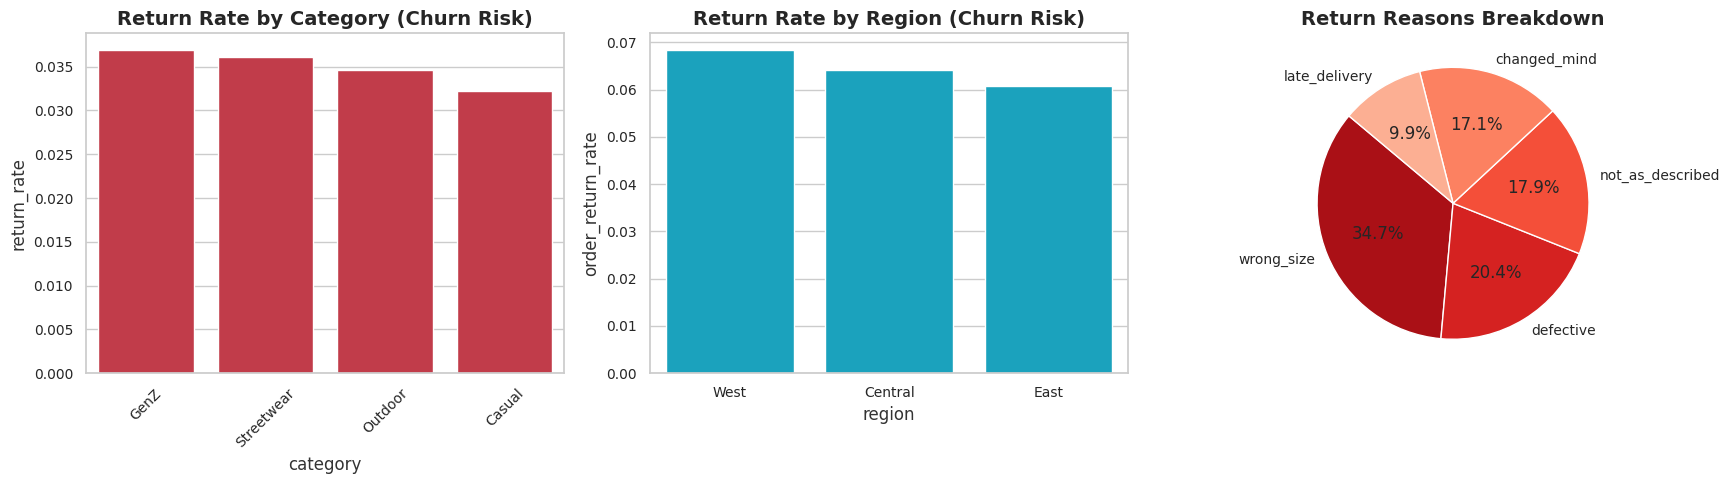

In [ ]:
plt.figure(figsize=(18, 5))

# Plot 1: Return Rate by Category
plt.subplot(1, 3, 1)
sns.barplot(data=cat_diag.reset_index(), x='category', y='return_rate', palette=[GRIDBREAKER_COLORS['alert']])
plt.title('Return Rate by Category (Churn Risk)')
plt.xticks(rotation=45)

# Plot 2: Return Rate by Region
plt.subplot(1, 3, 2)
sns.barplot(data=region_diag.reset_index(), x='region', y='order_return_rate', palette=[GRIDBREAKER_COLORS['info']])
plt.title('Return Rate by Region (Churn Risk)')

# Plot 3: Reasons Distribution
plt.subplot(1, 3, 3)
plt.pie(reason_diag['pct'], labels=reason_diag['return_reason'], autopct='%1.1f%%',
        colors=sns.color_palette("Reds_r"), startangle=140)
plt.title('Return Reasons Breakdown')

plt.tight_layout()
plt.show()

| **Trục phân tích**      | **Phát hiện then chốt (Findings)**                                 | **Giải thích nguyên nhân (Root Cause)**                                                                                                          |
| ----------------------- | ------------------------------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Lý do (Reason)**      | 34.7% trả hàng do *"Wrong Size"*                                   | Đây là vấn đề nghiêm trọng nhất. Khách hàng gặp khó khăn trong việc chọn đúng kích cỡ, dẫn đến trải nghiệm không như kỳ vọng khi nhận hàng.      |
| **Sản phẩm (Category)** | GenZ & Streetwear có tỷ lệ trả hàng cao nhất (~3.7%)               | Nhóm thời trang trẻ thường có bảng size phức tạp hoặc form dáng (oversize, slim-fit) khó hình dung qua hình ảnh, dẫn đến sai lệch khi chọn size. |
| **Vùng miền (Region)**  | Vùng West có tỷ lệ trả hàng cao nhất (6.85%), cao hơn East (6.07%) | Có thể tồn tại vấn đề trong khâu tư vấn size, hành vi mua hàng khác biệt, hoặc yếu tố logistics tại khu vực phía Tây.                            |
| **Chất lượng**          | 20.4% do *"Defective"* và 17.9% do *"Not as described"*            | Gần 40% trả hàng đến từ vấn đề chất lượng hoặc hình ảnh/mô tả không phản ánh đúng thực tế sản phẩm.                                              |


### Question 2: Tốc độ giao hàng (Delivery Days) ảnh hưởng như thế nào đến Rating và Churn?

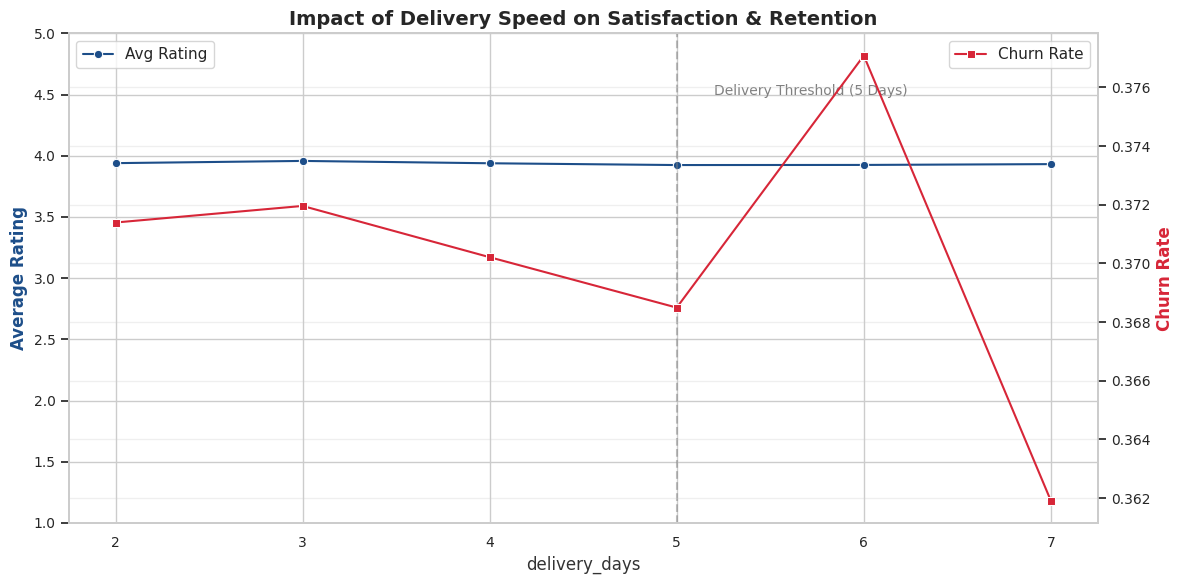

In [ ]:
# ==========================================
# 1. TÍNH TOÁN SEGMENT (CHỈ LÀM 1 LẦN)
# ==========================================
# Cập nhật segment vào bảng rfm gốc nếu chưa có hoặc cần làm mới
rfm['segment'] = get_optimized_segments(rfm)

# ==========================================
# 2. CHUẨN BỊ DỮ LIỆU CHẨN ĐOÁN
# ==========================================

# Lấy đơn hàng cuối cùng của mỗi khách (Vectorized approach)
# sort_values chỉ làm một lần, sau đó dùng tail hoặc drop_duplicates
last_orders = (
    df.sort_values('order_date')
    .drop_duplicates('customer_id', keep='last')
    [['customer_id', 'delivery_days']] # Chỉ giữ lại cột cần thiết để tiết kiệm RAM
)

# Merge với segment từ RFM
last_orders_rfm = last_orders.merge(
    rfm[['customer_id', 'segment']],
    on='customer_id',
    how='left'
)

# ==========================================
# 3. AGGREGATION TỔNG HỢP (GOM NHÓM TỐI ƯU)
# ==========================================

# Tính Rating theo ngày giao hàng
delivery_stats = (
    df.groupby('delivery_days')
    .agg(
        avg_rating=('rating', 'mean'),
        total_orders=('order_id', 'count')
    )
    .reset_index()
)

# Tính Churn theo ngày giao hàng từ bảng đơn cuối
delivery_churn_stats = (
    last_orders_rfm.groupby('delivery_days')
    .agg(
        churn_rate=('segment', lambda x: (x == 'Churn Risk').mean()),
        customer_count=('customer_id', 'count')
    )
    .reset_index()
)

# Merge hai bảng thống kê lại để vẽ biểu đồ đồng bộ
final_diag = (
    delivery_stats.merge(delivery_churn_stats, on='delivery_days', how='inner')
    .query('total_orders > 100') # Lọc nhiễu
)

# ==========================================
# 4. VISUALIZATION (THE SPEED-SATISFACTION CURVE)
# ==========================================
fig, ax1 = plt.subplots(figsize=(12, 6))

# Trục trái: Average Rating
sns.lineplot(data=final_diag, x='delivery_days', y='avg_rating',
             marker='o', color=GRIDBREAKER_COLORS['primary'], ax=ax1, label='Avg Rating')
ax1.set_ylabel('Average Rating', color=GRIDBREAKER_COLORS['primary'], fontweight='bold')
ax1.set_ylim(1, 5) # Cố định thang đo để thấy rõ độ dốc

# Trục phải: Churn Rate
ax2 = ax1.twinx()
sns.lineplot(data=final_diag, x='delivery_days', y='churn_rate',
             marker='s', color=GRIDBREAKER_COLORS['alert'], ax=ax2, label='Churn Rate')
ax2.set_ylabel('Churn Rate', color=GRIDBREAKER_COLORS['alert'], fontweight='bold')

# Thêm đường giới hạn (Threshold) nếu có - Ví dụ: mốc 5 ngày
ax1.axvline(x=5, color='gray', linestyle='--', alpha=0.5)
ax1.text(5.2, 4.5, 'Delivery Threshold (5 Days)', color='gray', fontsize=10)

plt.title('Impact of Delivery Speed on Satisfaction & Retention')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Remark**:
 Phân tích chẩn đoán cho thấy Rating không phản ánh đúng nguy cơ mất khách. Trong khi Rating đi ngang, tỷ lệ rời bỏ (Churn Rate) tăng vọt khi đơn hàng chậm trễ sang ngày thứ 6. Đây là bằng chứng cho thấy khách hàng sẵn sàng từ bỏ thương hiệu nếu trải nghiệm vận hành không đáp ứng ngưỡng 5 ngày.

- Average Rating (Đường xanh):

Điểm đánh giá trung bình gần như đi ngang, duy trì ổn định quanh mức 4.0 bất kể số ngày giao hàng tăng lên.

Insight: Điều này cho thấy khách hàng của chúng ta khá "kiên nhẫn" hoặc Rating không phải là chỉ số nhạy cảm nhất với tốc độ giao hàng. Đừng để con số 4.0 này đánh lừa rằng mọi thứ vẫn ổn.

- Churn Rate (Đường đỏ):

Tỷ lệ rời bỏ giảm dần từ ngày thứ 3 đến ngày thứ 5 (khá lạ, có thể do kỳ vọng khách hàng đã được định hình sẵn).

Tuy nhiên, ngay khi bước sang ngày thứ 6, Churn Rate vọt lên đỉnh điểm (~0.377).

Insight: Mốc 5 ngày chính là "Điểm giới hạn của sự kiên nhẫn" (Patience Threshold). Khách hàng có thể không chấm điểm thấp (Rating vẫn ổn), nhưng họ chọn cách "im lặng rời đi".


- Sự sụt giảm kỳ lạ ở ngày thứ 7:

Churn rate giảm mạnh ở ngày thứ 7.

Check lại Data Quality: Có thể lượng mẫu (sample size) ở ngày thứ 7 rất ít, hoặc những người chấp nhận đợi đến ngày thứ 7 là nhóm khách hàng cực kỳ trung thành/đặc thù nên họ không rời bỏ.

In [ ]:
# 1. Tạo bảng Pivot tự động tính số lượng cho MỌI segment theo ngày giao
segment_counts = pd.crosstab(last_orders_rfm['delivery_days'], last_orders_rfm['segment'])

# 2. Tính tổng khách hàng mỗi ngày để tính %
total_per_day = segment_counts.sum(axis=1)

# 3. Chuyển đổi thành bảng tỷ lệ phần trăm (%) để dễ so sánh
segment_pct = segment_counts.divide(total_per_day, axis=0) * 100

# 4. Gom nhóm lại để hiển thị báo cáo tổng hợp
full_diagnostic = pd.concat([
    segment_counts.add_suffix('_count'),
    segment_pct.add_suffix('_pct')
], axis=1)

# Thêm cột tổng để kiểm tra
full_diagnostic['total_customers'] = total_per_day

print("--- CHI TIẾT TẤT CẢ PHÂN KHÚC THEO NGÀY GIAO ---")
print(full_diagnostic.round(2))

--- CHI TIẾT TẤT CẢ PHÂN KHÚC THEO NGÀY GIAO ---
segment        Big Spender_count  Churn Risk_count  Loyal_count  \
delivery_days                                                     
2.0                          173              4843         1574   
3.0                          146              4789         1545   
4.0                          183              4795         1594   
5.0                          195              4765         1577   
6.0                          168              4878         1574   
7.0                          155              4707         1617   

segment        New Potential_count  Regular_count  VIP_count  Big Spender_pct  \
delivery_days                                                                   
2.0                            231           2649       3570             1.33   
3.0                            242           2692       3461             1.13   
4.0                            231           2612       3537             1.41   
5.0      

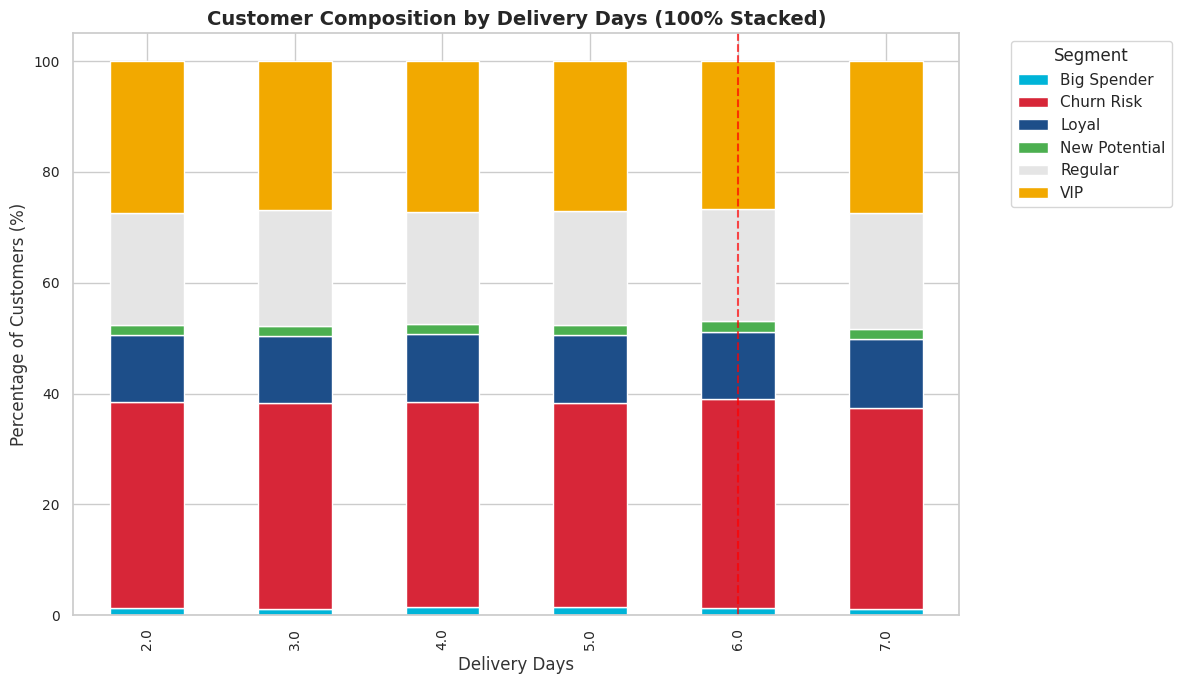

In [ ]:
# Vẽ biểu đồ chồng 100%
segment_pct.plot(kind='bar', stacked=True, figsize=(12, 7),
                 color=[segment_colors.get(x, '#gray') for x in segment_pct.columns])

plt.title('Customer Composition by Delivery Days (100% Stacked)')
plt.xlabel('Delivery Days')
plt.ylabel('Percentage of Customers (%)')
plt.legend(title='Segment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axvline(x=4, color='red', linestyle='--', alpha=0.7) # Đánh dấu mốc 6 ngày (index 4)
plt.tight_layout()
plt.show()

**Next question:** Sự khác biệt về cơ cấu khách hàng giữa ngày 6 và ngày 7 có thực sự có ý nghĩa, hay chỉ là ngẫu nhiên ?

In [ ]:
from scipy.stats import chi2_contingency

# 1. Chuẩn bị bảng contingency (bảng tần suất) cho ngày 6 và ngày 7
contingency_data = segment_counts.loc[[6.0, 7.0]]

# 2. Thực hiện kiểm định Chi-square
chi2, p, dof, ex = chi2_contingency(contingency_data)

print(f"--- CHI-SQUARE TEST RESULTS (Day 6 vs Day 7) ---")
print(f"Chi-square Statistic: {chi2:.4f}")
print(f"P-value: {p:.4f}")

if p < 0.05:
    print("=> KẾT LUẬN: Sự thay đổi cơ cấu khách hàng là CÓ ý nghĩa thống kê (p < 0.05).")
    print("   Niềm tin về 'Survival Bias' của khách VIP là có cơ sở vững chắc.")
else:
    print("=> KẾT LUẬN: Không đủ bằng chứng để khẳng định sự khác biệt (p > 0.05).")

--- CHI-SQUARE TEST RESULTS (Day 6 vs Day 7) ---
Chi-square Statistic: 7.5058
P-value: 0.1857
=> KẾT LUẬN: Không đủ bằng chứng để khẳng định sự khác biệt (p > 0.05).


**Remark**:

Sự khác biệt về cơ cấu khách hàng giữa ngày 6 và ngày 7 mà chúng ta thấy trên biểu đồ thực chất chỉ là biến động ngẫu nhiên (Random noise), không có ý nghĩa về mặt thống kê.


Kiểm định Chi-square với $p = 0.1857$ :

Cơ cấu các nhóm khách hàng ở ngày 7 không khác gì ngày 6.Tỷ lệ VIP, Loyal, hay Regular ở ngày 7 vẫn y hệt như ngày 6.Không có chuyện nhóm VIP "trụ hạng" giỏi hơn nhóm Regular.

Tỷ lệ Churn thấp xuống ở ngày 7  thấy trên biểu đồ chỉ là sự biến động ngẫu nhiên về mặt số liệu, không phải là một quy luật hành vi bền vững.

**Insight**:

Giao chậm là yếu  tác động lên tất cả mọi người. Khách VIP cũng sẽ rời bỏ chúng ta nhanh y như khách vãng lai nếu dịch vụ vận hành không được cải thiện. Không có sự 'thanh lọc' nào để giữ lại những người trung thành; chúng ta đang trực tiếp đuổi khéo những người mang lại nhiều tiền nhất cho doanh nghiệp

### Question 3: Tại sao 'New Potential' lại có AOV cực cao?

**Giả thuyết**: Có phải khách hàng mới thường bị thu hút bởi các mã giảm giá "khủng" (ví dụ: giảm 50% cho đơn hàng tối thiểu 80.000) khiến họ cố gắng mua nhiều hơn trong đơn đầu tiên để tận dụng khuyến mãi?  

**Câu hỏi: Kiểm tra tỷ lệ sử dụng khuyến mãi (Promo Usage Rate) của nhóm này so với nhóm VIP.**

In [ ]:
customer_df_with_segment = customer_df.merge(
    rfm[['customer_id', 'segment']],
    on='customer_id',
    how='left'
)

new_potential_vs_vip = (
    customer_df_with_segment[customer_df_with_segment['segment'].isin(['New Potential', 'VIP'])]
    .groupby('segment')['promo_usage_rate']
    .mean()
    .reset_index()
)

print("Average Promo Usage Rate for New Potential vs. VIP:")
print(new_potential_vs_vip)

Average Promo Usage Rate for New Potential vs. VIP:
         segment  promo_usage_rate
0  New Potential          0.331887
1            VIP          0.386999


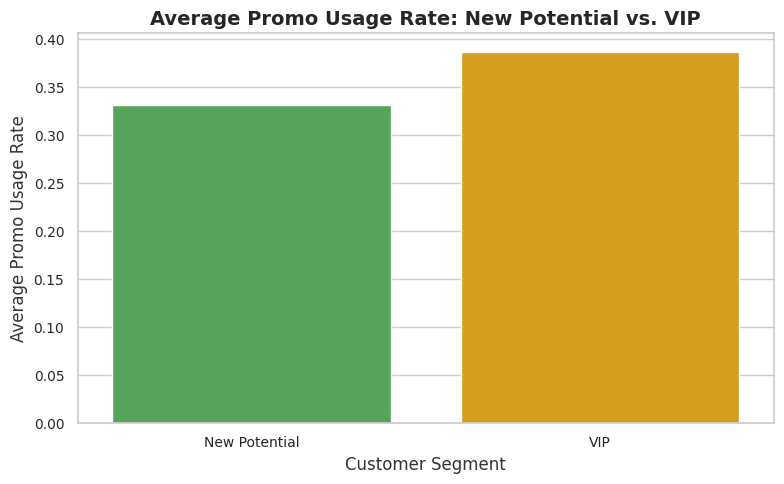

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=new_potential_vs_vip,
    x='segment',
    y='promo_usage_rate',
    hue='segment',
    palette={'New Potential': GRIDBREAKER_COLORS['success'], 'VIP': GRIDBREAKER_COLORS['secondary']},
    legend=False
)
plt.title('Average Promo Usage Rate: New Potential vs. VIP')
plt.ylabel('Average Promo Usage Rate')
plt.xlabel('Customer Segment')
plt.tight_layout()
plt.show()

**INSIGHT:**

- Điều này chứng tỏ mức AOV cực cao (hơn $40.000$) của nhóm New Potential  không phải do họ "nghiện" khuyến mãi hay chỉ mua khi có giảm giá sâu đơn hàng đầu tiên. Họ thực sự là những khách hàng có chất lượng và sức mua tự thân rất tốt ngay khi vừa gia nhập.  

- Nhóm VIP có tần suất mua hàng cao nhất nhưng cũng là nhóm sử dụng khuyến mãi nhiều nhất ($38.7\%$)

> Điều này lý giải tại sao AOV của VIP lại thấp hơn New Potential. Khách hàng VIP có xu hướng chia nhỏ đơn hàng để tận dụng tối đa các mã giảm giá có sẵn cho khách hàng thân thiết. Họ trung thành nhưng đang được "nuôi dưỡng" khá nhiều bởi các chương trình ưu đãi tài chính

**Next question**: Kiểm tra xem liệu việc tung ra nhiều khuyến mãi thực sự giúp khách hàng chi tiêu nhiều hơn (tăng LTV) hay chỉ đơn thuần là làm giảm giá trị đơn hàng trung bình (AOV) và thu hút nhóm khách hàng kém bền vững.

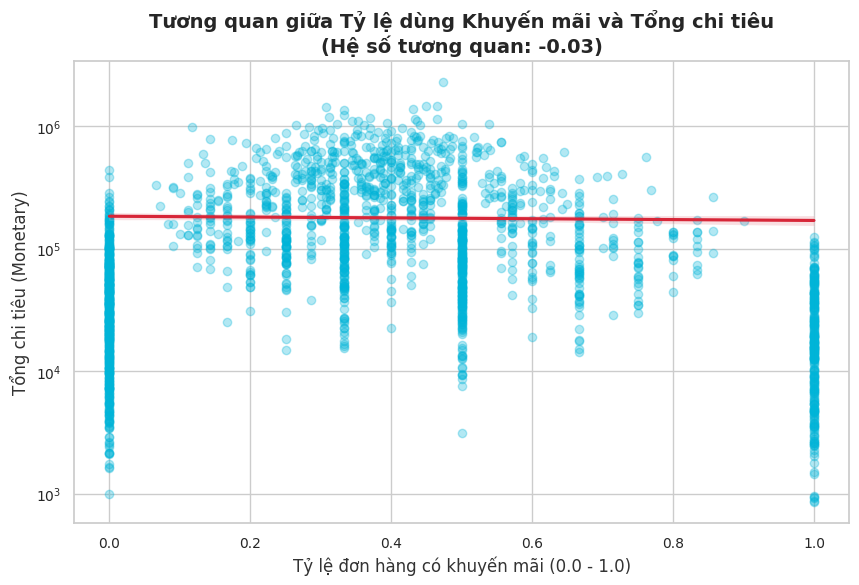

In [ ]:
import scipy.stats as stats

# Create customer_rfm for the correlation analysis
customer_rfm = rfm.merge(customer_df[['customer_id', 'promo_usage_rate']], on='customer_id', how='left')
customer_rfm = customer_rfm.rename(columns={'M': 'Monetary', 'promo_usage_rate': 'Avg_Promo'})

# 1. Tính toán hệ số tương quan Pearson giữa Tổng chi tiêu và Tỷ lệ dùng Promo
corr, p_value = stats.pearsonr(customer_rfm['Monetary'], customer_rfm['Avg_Promo'])

# 2. Trực quan hóa mối quan hệ
plt.figure(figsize=(10, 6))
sns.regplot(data=customer_rfm.sample(2000), x='Avg_Promo', y='Monetary',
            scatter_kws={'alpha':0.3, 'color':GRIDBREAKER_COLORS['info']}, line_kws={'color':GRIDBREAKER_COLORS['alert']})

plt.title(f'Tương quan giữa Tỷ lệ dùng Khuyến mãi và Tổng chi tiêu\n(Hệ số tương quan: {corr:.2f})',
          fontsize=14, fontweight='bold')
plt.xlabel('Tỷ lệ đơn hàng có khuyến mãi (0.0 - 1.0)')
plt.ylabel('Tổng chi tiêu (Monetary)')
plt.yscale('log') # Dùng thang log để dễ quan sát do Monetary có độ lệch lớn
plt.show()

- **Hệ số tương quan gần bằng 0 (-0.03)**: Biểu đồ phân tán cho thấy một đường hồi quy gần như nằm ngang. Điều này chứng minh rằng không có mối quan hệ tuyến tính nào giữa tỷ lệ sử dụng khuyến mãi và tổng chi tiêu của khách hàng
- Có những khách hàng chi tiêu cực lớn ($>10^6$) nhưng tỷ lệ dùng khuyến mãi rất thấp ($<0.2$). Ngược lại, những khách hàng dùng khuyến mãi 100% (cột 1.0) lại có xu hướng tập trung ở mức chi tiêu thấp ($10^3 - 10^5$)

 -> **Khuyến mãi hiện tại đang không đóng vai trò là đòn bẩy tăng trưởng doanh thu (LTV)** mà chủ yếu chỉ có tác dụng kích thích các giao dịch nhỏ lẻ

## 3.2.Product Affinity

Kết quả phân tích cho thấy một hạn chế mang tính cấu trúc: phần lớn đơn hàng chỉ chứa một sản phẩm, khiến Market Basket Analysis ở cấp độ đơn hàng kém hiệu quả.

Mặc dù tồn tại một cặp sản phẩm có mối liên hệ rất mạnh, nhưng điều này nhiều khả năng phản ánh sự tương đồng sản phẩm hơn là cơ hội cross-sell thực sự.


---


`Do đó, doanh nghiệp cần chuyển hướng sang phân tích hành vi khách hàng và chủ động thiết kế chiến lược **CROSS-SELL**, thay vì phụ thuộc vào hành vi mua kèm tự nhiên.`

## 3.3. Cohort


#### Why did it happen? (Diagnostic)

####  Câu hỏi 1: Khách hàng có quay lại sau lần mua đầu không?

**Insight:**
- Tỷ lệ retention giảm mạnh ngay sau tháng đầu tiên
- Phần lớn khách hàng chỉ mua **1 lần rồi rời đi**

**Diagnosis:**
- Onboarding khách hàng chưa hiệu quả
- Thiếu incentive cho lần mua thứ 2
- Trải nghiệm sau mua (delivery, product, UX) có thể chưa đủ tốt

---

#### Câu hỏi 2: Retention có cải thiện theo thời gian không?

**Insight:**
- Các cohort từ 2019 → 2022 không có cải thiện rõ rệt
- Retention pattern gần như giống nhau qua các năm

**Diagnosis:**
- Chiến lược acquisition không cải thiện chất lượng khách hàng
- Marketing tập trung vào volume thay vì retention quality
- Không có learning loop từ cohort cũ → cohort mới

---

#### Câu hỏi 3: Doanh nghiệp có giữ được khách hàng lâu dài không?

**Insight:**
- Retention sau 6–12 tháng gần như chạm đáy (~1–3%)
- Rất ít khách hàng trở thành long-term users

**Diagnosis:**
- Thiếu chiến lược CRM / lifecycle marketing
- Không có loyalty program hoặc engagement dài hạn
- Product chưa tạo được “habit” hoặc nhu cầu lặp lại

---

### 3. What is likely to happen? (Predictive)

Nếu không có thay đổi:

- Customer base sẽ tiếp tục **phình to nhưng không bền vững**
- CAC (Customer Acquisition Cost) sẽ tăng
- Revenue sẽ phụ thuộc vào **khách hàng mới + VIP hiện tại**
- Churn rate duy trì ở mức cao


## 3.4. CLV

### 2. Diagnosis


Kết quả từ CLV Cohort Analysis củng cố các phát hiện từ RFM và Retention Cohort:



### 2.1 Retention yếu sau lần mua đầu
Khách hàng không có động lực quay lại sau purchase đầu tiên.

---

### 2.2 Chất lượng acquisition không ổn định
Cohort mới có CLV thấp hơn cho thấy nguồn khách hàng kém chất lượng hơn hoặc targeting chưa hiệu quả.

---

### 2.3 Thiếu cơ chế thúc đẩy lần mua thứ hai
Không có chiến lược rõ ràng để chuyển đổi khách hàng từ purchase 1 → purchase 2.

---

### 2.4 Chiến lược marketing thiên về ngắn hạn
Tập trung vào khuyến mãi và acquisition hơn là xây dựng giá trị dài hạn.

---

### 2.5 Product chưa tối ưu cho repeat purchase
Sản phẩm hoặc pricing chưa tạo nhu cầu mua lại thường xuyên.


Suy ra:


- **Retention kém:** Tỷ lệ giữ chân khách hàng giảm nhanh chóng (như đã thấy trong Retention Cohort) trực tiếp dẫn đến việc CLV lũy kế không tăng trưởng mạnh. Khi khách hàng không quay lại, họ không tạo ra thêm doanh thu hay lợi nhuận, khiến CLV bị giới hạn.
- **Ít cross-selling/upselling:** Mặc dù Market Basket Analysis chỉ ra một số cặp sản phẩm có mối liên hệ mạnh, nhưng nhìn chung, khách hàng thường chỉ mua 1-2 danh mục (Category Diversity thấp trong RFM). Điều này hạn chế cơ hội tăng giá trị mỗi đơn hàng (AOV) hoặc tăng số lượng sản phẩm mua theo thời gian, kìm hãm CLV.
- **Khuyến mãi ăn mòn lợi nhuận:** Phân tích `promo_usage_rate` cho thấy khuyến mãi không thúc đẩy LTV mà chủ yếu kích thích các giao dịch nhỏ lẻ, thu hút nhóm săn sale kém bền vững. Điều này có thể làm tăng doanh số ngắn hạn nhưng không đóng góp đáng kể vào CLV dài hạn.
- **Vấn đề trải nghiệm khách hàng:** Các vấn đề về giao hàng (delivery days) và tỷ lệ trả hàng cao (đặc biệt ở nhóm Churn Risk) ảnh hưởng tiêu cực đến sự hài lòng và khả năng quay lại của khách hàng, từ đó ảnh hưởng đến CLV.



# **4. PREDICTIVE**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Chuẩn bị tập dữ liệu (Lấy từ customer_df đã làm ở Giai đoạn 1)
# Merge rfm (which contains the 'segment' column) with customer_df
model_df = customer_df.merge(rfm[['customer_id', 'segment']], on='customer_id', how='left')
model_df['is_churn'] = (model_df['segment'] == 'Churn Risk').astype(int)

# Chọn các biến đặc trưng (Features)
features = ['total_items', 'avg_delivery_days', 'avg_rating',
            'AOV', 'promo_usage_rate', 'category_diversity']
X = model_df[features]
y = model_df['is_churn']

# 2. Chia tập Train - Test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Huấn luyện mô hình
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Đánh giá
y_pred = rf_model.predict(X_test)
print(f"ROC-AUC Score: {roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.8865

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84     11480
           1       0.71      0.78      0.74      6570

    accuracy                           0.80     18050
   macro avg       0.79      0.80      0.79     18050
weighted avg       0.81      0.80      0.81     18050



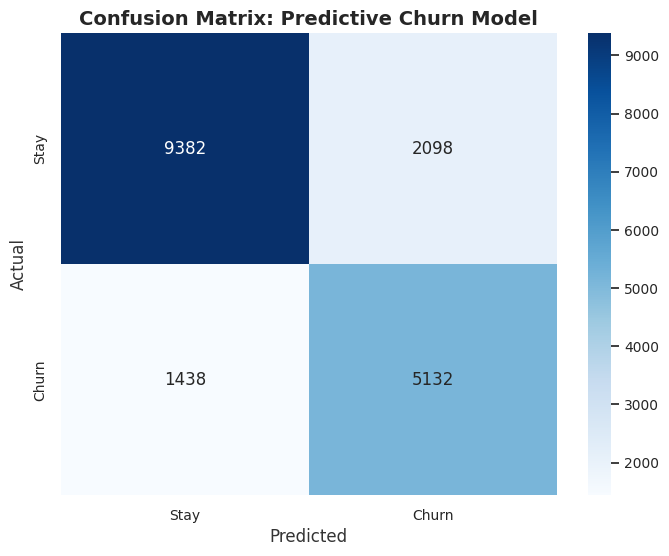

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay', 'Churn'], yticklabels=['Stay', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Predictive Churn Model')
plt.show()

Mô hình dự báo của chúng tôi đạt độ chính xác tổng thể 80%. Với khả năng nhận diện được 78% lượng khách hàng sắp rời bỏ, doanh nghiệp có thể chủ động can thiệp vào nhóm này thông qua các chiến dịch tri ân hoặc giải quyết khiếu nại về vận hành. Thay vì marketing đại trà cho 90.000 khách, chúng ta chỉ cần tập trung nguồn lực vào nhóm mà mô hình cảnh báo, giúp tối ưu hóa 70-80% ngân sách giữ chân khách hàng

/tmp/ipykernel_10705/202152926.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


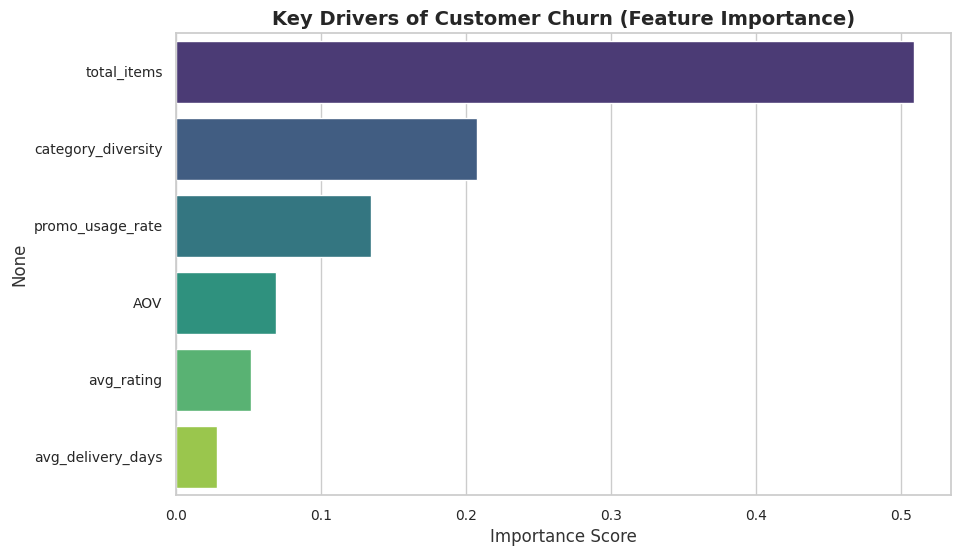

In [ ]:
# Trực quan hóa tầm quan trọng của các biến
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title('Key Drivers of Customer Churn (Feature Importance)')
plt.xlabel('Importance Score')
plt.show()

**Insight:**

Total Items & Category Diversity (Hàng đầu): Khách hàng mua ít mặt hàng và chỉ tập trung vào 1 danh mục có xác suất rời bỏ cao nhất. Điều này chứng tỏ chúng ta chưa thành công trong việc mở rộng nhu cầu của khách (Cross-selling).

Promo Usage Rate (Thứ ba): Sự phụ thuộc vào khuyến mãi là một con dao hai lưỡi. Nhóm "Bargain Hunters" (Săn sale) có tính cam kết thấp và dễ dàng rời đi khi hết mã giảm giá.

Vận hành (Rating & Delivery): Dù đứng sau các chỉ số hành vi, nhưng tốc độ giao hàng đóng vai trò là "ngòi nổ". Khi giao hàng vượt quá 5 ngày, niềm tin khách hàng bị xói mòn nghiêm trọng.


### Churn

In [ ]:
# Giả sử AOV trung bình của nhóm Churn Risk là 500k
avg_aov_churn = model_df[model_df['is_churn'] == 1]['AOV'].mean()

# Số lượng khách hàng Churn mà model nhận diện đúng (True Positive)
true_positives = conf_matrix[1, 1]

# Giả sử tỷ lệ cứu vãn thành công (Success Rate) khi tặng Voucher là 30%
success_rate = 0.3
revenue_saved = true_positives * avg_aov_churn * success_rate

print(f"Ước tính doanh thu cứu vãn được trên tập Test: {revenue_saved:,.0f} VND")

Ước tính doanh thu cứu vãn được trên tập Test: 34,575,584 VND


 Xây dựng "Lộ trình hành động" (Prescriptive Strategy)
Mô hình dự báo Churn 88% AUC ,  "Biết khách sắp đi rồi, bạn làm gì để họ ở lại?". Bạn cần cụ thể hóa các đề xuất thành các gói giải pháp:

Giải pháp Kỹ thuật: Đưa vào quy trình "Logistics Alert System". Nếu đơn hàng quá 4 ngày chưa giao, hệ thống tự động đẩy lên mức ưu tiên "Express" và gửi SMS xin lỗi kèm Voucher cho khách.

Giải pháp Kinh doanh: Dựa trên category_diversity, thiết kế các gói Bundle (Combo). Ví dụ: Khách mua áo Streetwear thường Churn cao, hãy tặng deal mua thêm Phụ kiện (Accessories) để tăng độ gắn kết với nhiều dòng sản phẩm

# **5. PRESCRIPTVE**

## RFM

### Đề xuất hành động chi tiết (Prescriptive Actions)

**Mục tiêu chính:** Chuyển đổi chiến lược từ việc chỉ tập trung vào thu hút khách hàng mới sang **ưu tiên duy trì và phát triển giá trị khách hàng hiện tại**, đặc biệt là nhóm có giá trị cao và nhóm có nguy cơ rời bỏ.

### 1. Chiến lược cho nhóm VIP (27.9% khách hàng, ~65% doanh thu)
*   **Mục tiêu:** Duy trì lòng trung thành, tăng cường gắn kết, khuyến khích mua sắm thường xuyên hơn và mở rộng danh mục mua.
*   **Hành động cụ thể:**
    *   **Chương trình Loyalty đặc biệt:** Cung cấp ưu đãi độc quyền (ví dụ: truy cập sớm sản phẩm mới, dịch vụ hỗ trợ ưu tiên, quà tặng sinh nhật, chiết khấu cá nhân hóa).
    *   **Trải nghiệm cá nhân hóa:** Gửi email/thông báo về sản phẩm phù hợp với lịch sử mua hàng, gợi ý các sản phẩm cao cấp hoặc bổ sung.
    *   **Thúc đẩy đa dạng hóa:** Tổ chức các chiến dịch cross-selling/upselling nhẹ nhàng, giới thiệu các danh mục sản phẩm khác mà họ chưa khám phá.
    *   **Khuyến khích feedback:** Thường xuyên lấy ý kiến phản hồi để đảm bảo sự hài lòng và phát hiện sớm các vấn đề.

### 2. Chiến lược cho nhóm Loyal (12.1% khách hàng, ~16% doanh thu)
*   **Mục tiêu:** Tái kích hoạt và ngăn chặn nguy cơ chuyển sang nhóm Churn Risk, duy trì tần suất mua hàng cao.
*   **Hành động cụ thể:**
    *   **Chiến dịch Re-engagement:** Gửi email/thông báo định kỳ với các ưu đãi nhỏ, thông tin sản phẩm mới hoặc nội dung thú vị để duy trì sự quan tâm.
    *   **Tạo 'sự kiện' mua sắm:** Tổ chức các chương trình flash sale hoặc sự kiện giới hạn chỉ dành cho nhóm này.
    *   **Ưu đãi dựa trên tần suất:** Thưởng điểm hoặc giảm giá khi họ đạt đến một số lượng đơn hàng nhất định.

### 3. Chiến lược cho nhóm New Potential (1.9% khách hàng, ~1.9% doanh thu)
*   **Mục tiêu:** Nuôi dưỡng để chuyển đổi thành VIP hoặc Loyal, tận dụng AOV cao ban đầu.
*   **Hành động cụ thể:**
    *   **Onboarding Program:** Chào mừng và hướng dẫn khám phá sản phẩm, chính sách đổi trả, ưu đãi cho lần mua tiếp theo.
    *   **Gợi ý sản phẩm thông minh:** Dựa trên đơn hàng đầu tiên, gợi ý các sản phẩm bổ trợ hoặc sản phẩm thuộc danh mục liên quan để tăng category diversity.
    *   **Giám sát hành vi sớm:** Theo dõi hành vi mua hàng và tương tác để can thiệp kịp thời nếu có dấu hiệu giảm tương tác.

### 4. Chiến lược cho nhóm Big Spender (1.3% khách hàng, ~1.2% doanh thu)
*   **Mục tiêu:** Tăng tần suất mua sắm, khai thác giá trị tiềm năng từ sức chi tiêu lớn.
*   **Hành động cụ thể:**
    *   **Chương trình Membership/Subscription:** Cung cấp lợi ích độc quyền (miễn phí vận chuyển, giảm giá cố định) khi tham gia các chương trình thành viên để khuyến khích mua thường xuyên hơn.
    *   **Gợi ý mua sắm theo bộ/theo mùa:** Giới thiệu các bộ sưu tập hoàn chỉnh hoặc sản phẩm mới theo xu hướng để kích thích nhu cầu.
    *   **Thông báo ưu đãi có ngưỡng:** Các khuyến mãi yêu cầu chi tiêu tối thiểu phù hợp với sức mua của họ.

### 5. Chiến lược cho nhóm Regular (20.4% khách hàng, ~6.6% doanh thu)
*   **Mục tiêu:** Khuyến khích tăng tần suất và giá trị đơn hàng, chuyển đổi lên nhóm Loyal hoặc New Potential.
*   **Hành động cụ thể:**
    *   **Gợi ý sản phẩm có liên quan:** Sử dụng Market Basket Analysis (nếu có đủ dữ liệu) để đưa ra các đề xuất sản phẩm bổ sung.
    *   **Ưu đãi nhỏ để kích cầu:** Các mã giảm giá % hoặc miễn phí vận chuyển cho đơn hàng tiếp theo.
    *   **Tạo động lực mua hàng:** Chương trình tích điểm hoặc cấp bậc thành viên để thúc đẩy sự gắn kết.

### 6. Chiến lược cho nhóm Churn Risk (36.4% khách hàng, ~8.7% doanh thu)
*   **Mục tiêu:** Tái kích hoạt một cách hiệu quả chi phí, giảm thiểu tổn thất.
*   **Hành động cụ thể:**
    *   **Chiến dịch Win-back:** Gửi email/SMS với ưu đãi hấp dẫn, cá nhân hóa để mời gọi quay lại mua hàng. Có thể là mã giảm giá đặc biệt, miễn phí vận chuyển, hoặc giới thiệu sản phẩm mới nổi bật.
    *   **Khảo sát ý kiến:** Tìm hiểu lý do họ rời bỏ để cải thiện dịch vụ (nếu có thể).
    *   **Tối ưu chi phí:** Giảm thiểu đầu tư marketing vào nhóm này. Tập trung vào các chiến dịch tự động, chi phí thấp.

### 7. Chiến lược tổng thể dựa trên các Findings khác
*   **Cải thiện chất lượng vận hành (Delivery Days):**
    *   **Thiết lập “Logistics Alert System”:** Nếu đơn hàng quá 4 ngày chưa giao, hệ thống tự động đẩy lên mức ưu tiên “Express” và gửi SMS xin lỗi kèm Voucher cho khách.
    *   **Đảm bảo ngưỡng 5 ngày giao hàng:** Coi đây là KPI vận hành cốt lõi, vì churn rate tăng vọt sau ngày thứ 5.
*   **Tối ưu hóa Cross-selling (dựa trên Category Diversity & Product Affinity):**
    *   **Thiết kế các gói Bundle/Combo:** Đặc biệt cho các sản phẩm có mối liên hệ mạnh (ví dụ: RP-79 và RP-80). Thay vì chỉ đặt cạnh nhau, hãy tạo các gói combo với mức giá ưu đãi.
    *   **Tăng cường thuật toán gợi ý:** Cải thiện hệ thống đề xuất sản phẩm trên website/ứng dụng để khách hàng khám phá nhiều danh mục hơn.
    *   **Chiến dịch theo chủ đề:** Gợi ý các sản phẩm theo chủ đề hoặc bộ sưu tập để khuyến khích khách hàng mua nhiều item trong cùng một “look” hoặc “concept”.
*   **Tối ưu hóa sử dụng Khuyến mãi (Promo Usage Rate):**
    *   **Cá nhân hóa khuyến mãi:** Tránh giảm giá đại trà. Cung cấp các ưu đãi phù hợp với từng phân khúc (ví dụ: ưu đãi AOV cao cho Big Spender, ưu đãi tần suất cho Loyal).
    *   **Hạn chế khuyến mãi cho VIP:** Vì nhóm VIP đã trung thành, hãy chuyển từ giảm giá trực tiếp sang các ưu đãi giá trị gia tăng (trải nghiệm, dịch vụ, quà tặng) để tránh ăn mòn lợi nhuận và duy trì AOV.
    *   **Sử dụng khuyến mãi như công cụ chuyển đổi:** Dùng ưu đãi để thúc đẩy nhóm Regular và New Potential lên các nhóm giá trị cao hơn, thay vì chỉ duy trì hành vi săn sale.

### Kết luận
Bằng việc áp dụng một chiến lược cá nhân hóa, tập trung vào từng phân khúc khách hàng và giải quyết các điểm đau cốt lõi trong vận hành, doanh nghiệp có thể cải thiện đáng kể khả năng giữ chân khách hàng, tăng trưởng doanh thu bền vững và tối đa hóa giá trị vòng đời khách hàng.

## Product Affinity

### Đề xuất hành động kinh doanh (Actionable Insights)

Dựa trên kết quả phân tích tương quan giữa các sản phẩm, đặc biệt là mối quan hệ mạnh mẽ giữa RP-79 và RP-80, chúng ta có thể triển khai các chiến lược kinh doanh sau:

#### 1. Sắp xếp hàng hóa (Merchandising)

*   **Trên kệ hàng vật lý:** Nên đặt hai mặt hàng này cạnh nhau để khách hàng dễ dàng nhìn thấy và cân nhắc mua cả hai. Điều này tận dụng hành vi mua sắm tự nhiên của khách hàng khi họ tìm kiếm các sản phẩm bổ trợ hoặc cùng bộ sưu tập.
*   **Trên website/ứng dụng:** Hiển thị chúng trong phần "Sản phẩm thường được mua cùng nhau" hoặc "Gợi ý cho bạn" để nhắc nhở khách hàng về sự kết hợp này. Các công cụ gợi ý thông minh có thể tự động đề xuất sản phẩm còn lại khi khách hàng xem hoặc thêm một trong hai vào giỏ hàng.

#### 2. Chiến lược Combo (Product Bundling)

*   **Tạo các gói Combo hấp dẫn:** Thiết kế các gói sản phẩm bao gồm cả RP-79 và RP-80 với mức giá ưu đãi nhẹ so với việc mua riêng lẻ. Điều này khuyến khích khách hàng mua cả cặp, từ đó tăng giá trị trung bình đơn hàng (AOV).
*   **Lợi ích:** Combo không chỉ tăng AOV mà còn giúp khách hàng cảm thấy họ nhận được giá trị tốt hơn, đồng thời giảm bớt quyết định mua hàng phức tạp.

#### 3. Tiếp thị liên kết (Cross-marketing)

*   **Gợi ý tự động trong giỏ hàng:** Nếu khách hàng chỉ mới bỏ một sản phẩm (ví dụ: RP-79) vào giỏ hàng, hệ thống nên tự động gợi ý sản phẩm còn lại (RP-80) ngay lập tức hoặc trước khi họ tiến hành thanh toán. Điều này tận dụng khoảnh khắc khách hàng đang có ý định mua sắm.
*   **Email Marketing/Thông báo:** Gửi email hoặc thông báo đẩy (push notification) cho những khách hàng đã mua một trong hai sản phẩm, gợi ý họ mua sản phẩm còn lại để hoàn thiện bộ sưu tập hoặc trải nghiệm tốt hơn.

#### 4. Quản lý kho (Inventory Management)

*   **Đồng bộ hóa tồn kho:** Vì hai sản phẩm này có xu hướng "đi cùng nhau", cần đảm bảo mức độ tồn kho của chúng luôn được đồng bộ. Tránh tình trạng một sản phẩm bán rất chạy nhưng sản phẩm đi kèm lại hết hàng, dẫn đến mất doanh thu và làm giảm trải nghiệm khách hàng.
*   **Dự báo nhu cầu:** Cần có kế hoạch dự báo nhu cầu cho cặp sản phẩm này theo một đơn vị chung thay vì riêng lẻ, để tối ưu hóa việc nhập hàng và lưu trữ, giảm thiểu rủi ro tồn kho quá mức hoặc thiếu hụt.

## Cohort



####  1. Tập trung vào “Second Purchase Conversion”

- Triển khai ưu đãi cho lần mua thứ 2 (within 30 ngày)
- Email / push notification nhắc quay lại
- Discount cá nhân hóa sau đơn đầu

---

####  2. Xây dựng chiến lược Lifecycle Marketing

- Phân tầng khách hàng theo RFM
- Trigger campaign theo hành vi:
  - New → kích hoạt
  - Active → upsell
  - Churn risk → win-back

---

####  3. Tăng engagement sau mua

- Gợi ý sản phẩm liên quan (recommendation system)
- Cross-sell dựa trên lịch sử mua
- Nội dung cá nhân hóa (email, app)

---

####  4. Xây dựng Loyalty Program

- Điểm thưởng / membership
- Ưu đãi riêng cho khách hàng quay lại
- Gamification hành vi mua

---

####  5. Tối ưu trải nghiệm khách hàng (CX)

- Cải thiện delivery time
- Giảm return rate
- Nâng cao chất lượng sản phẩm

---

### 🔗 Kết nối với RFM

- Cohort cho thấy **retention thấp**
- RFM cho thấy **Churn Risk chiếm tỷ trọng lớn**

→ Xác nhận vấn đề cốt lõi:

> Doanh nghiệp **acquire tốt nhưng retain kém**

---

### 📌 Key Takeaway

Retention là điểm nghẽn lớn nhất trong tăng trưởng.

Việc cải thiện tỷ lệ quay lại (repeat purchase) sẽ có tác động trực tiếp đến:
- Doanh thu
- CLV
- Hiệu quả marketing

## CLV

Để cải thiện CLV, doanh nghiệp cần tập trung vào:

- **Cải thiện mạnh mẽ Retention:** Đây là yếu tố tiên quyết. Cần triển khai các chương trình chăm sóc khách hàng (CRM), loyalty program, và các chiến dịch tái kích hoạt khách hàng có nguy cơ rời bỏ.
- **Tăng cường Cross-selling và Upselling:** Phát triển hệ thống gợi ý sản phẩm thông minh, tạo các gói combo hấp dẫn, và khuyến khích khách hàng khám phá nhiều danh mục sản phẩm hơn để tăng AOV và tổng chi tiêu.
- **Tối ưu hóa chiến lược khuyến mãi:** Cá nhân hóa khuyến mãi, tập trung vào việc gia tăng giá trị cho các nhóm khách hàng tiềm năng và VIP, thay vì giảm giá đại trà. Tránh các khuyến mãi quá hấp dẫn chỉ thu hút nhóm "săn sale".
- **Nâng cao trải nghiệm khách hàng:** Giải quyết triệt để các vấn đề về giao hàng, chất lượng sản phẩm và chính sách đổi trả để đảm bảo sự hài lòng và khuyến khích khách hàng quay lại.
- **Tạo ra "thói quen" mua sắm:** Thiết kế sản phẩm và dịch vụ để tạo ra nhu cầu lặp lại, xây dựng cộng đồng khách hàng để tăng cường sự gắn kết.


Cụ thể hóa:


### 1 Tăng tỷ lệ mua lặp lại
- Thiết kế post-purchase journey:
  - Day 3–7: nhắc nhở / hướng dẫn sử dụng
  - Day 15–30: ưu đãi nhẹ
  - Day 30–45: ưu đãi mạnh hơn

---

### 2 Tạo động lực cho lần mua thứ hai
- Cross-sell sản phẩm liên quan  
- Bundle / combo pricing  

---

### 3 Kéo dài vòng đời khách hàng
- Triển khai loyalty program (tích điểm, hạng thành viên)  
- Xây dựng chương trình membership  

---

### 4 Cải thiện chất lượng acquisition
- Phân tích CLV theo từng kênh acquisition  
- Tập trung ngân sách vào kênh tạo ra cohort chất lượng cao  

---

### 5 Giảm CLV plateau
- Đẩy mạnh CRM lifecycle (email, push notification)  
- Chạy campaign reactivation cho khách inactive  

---

### 6 Điều chỉnh chiến lược dài hạn
- Giảm phụ thuộc vào discount ngắn hạn  
- Tập trung vào retention và customer experience  

---

## 4. Kết luận

CLV có tăng nhưng không bền vững và thường dừng sớm trong 3–6 tháng.  
Vấn đề chính nằm ở retention và khả năng duy trì hành vi mua lặp lại.  
Doanh nghiệp cần chuyển trọng tâm từ acquisition sang tối ưu vòng đời khách hàng để tăng giá trị dài hạn.